# Practical backtesting for Polymarket, with h5i-db

Prediction markets are the friendliest asset class to reason about and one of
the least forgiving to backtest. A Polymarket share pays exactly one dollar if
the event happens and zero if it does not, so the price is a probability, the
maximum loss is the price you paid, and every profit-and-loss question has an
arithmetic answer rather than a modelling one. That clarity is exactly what
makes the failure mode so easy to walk into: because the payoff is obvious,
people write backtests that assume they bought at the price they saw on the
screen, and the entire difference between a strategy that works on paper and
one that works in an account lives in that assumption.

This article builds the whole loop, end to end, and every number in it is
produced by code you can run. It goes in three parts.

1. **How a Polymarket price is actually made.** The central limit order book,
   the price ladder, and what happens mechanically when you send an order into
   it. We will walk a market order through a real ladder by hand and count the
   cost of a round trip before writing a single line of strategy code.
2. **A twelve-event toy market.** One instrument, a book small enough to print
   in full, and four strategies that all see exactly the same data and end up
   in four very different places. The differences are entirely execution, and
   the toy is small enough that you can check the engine's arithmetic against
   your own.
3. **Real tick-level Polymarket books.** The same machinery on a public capture
   of real order books with real UMA-verified outcomes, running eleven standard
   strategies, decomposing where the money went, and validating the result with
   walk-forward windows and a deflated Sharpe ratio.

The third part has a negative result: on this data, every one of the eleven
standard rules loses money. That is deliberate. An article that showed you a
winning strategy on one day of six markets would be teaching you to fool
yourself, and the machinery you need to *establish* that a rule does not work
is precisely the machinery you need before you believe one that does.

The database underneath is [h5i-db](https://github.com/h5i-dev/h5i-db), an
embedded, versioned time-series store with an event-driven backtest engine
built into it. Nothing here needs a server, an account, or a cluster: it is a
directory on disk plus a Python import.

## Vocabulary, once, up front

Prediction markets borrow their jargon from equities trading, and most of it is
obvious once someone says it out loud. Every term below is used later in the
article, and each one is also explained again in context where it first
matters.

| term | meaning |
|---|---|
| **share / contract** | the tradeable unit; one YES share pays \$1.00 if the event happens, \$0.00 otherwise |
| **YES token / NO token** | the two sides of a binary market, each a separately tradeable asset |
| **price** | what you pay for one share, between 0 and 1, which is also the market's implied probability |
| **order book (CLOB)** | the list of everyone's resting buy and sell orders, sorted by price |
| **bid** | the highest price anyone is currently willing to *pay* for a share |
| **ask (offer)** | the lowest price anyone is currently willing to *sell* a share for |
| **spread** | ask minus bid, the gap between the two, and the cost of an instant round trip |
| **mid** | the midpoint `(bid + ask) / 2`, the usual "the price is X" number |
| **depth / size** | how many shares are resting at a given price level |
| **level** | one row of the book: a price plus the size resting at it |
| **maker** | someone who posts an order and waits for a counterparty |
| **taker** | someone who crosses the spread and trades immediately against a resting order |
| **market order** | trade now at whatever the book offers |
| **limit order** | trade only at this price or better, and wait if necessary |
| **fill** | an execution; the actual price and quantity you got, as opposed to what you asked for |
| **slippage** | the difference between the price you decided on and the price you got |
| **resolution / settlement** | the market's outcome being finalised, after which shares pay \$1 or \$0 |
| **round trip** | one buy and the sell that closes it, which is where costs are paid |
| **realized P&L** | profit from positions you actually closed |
| **settlement P&L** | profit from positions still open when the market resolved |

In [1]:
import datetime as dt
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow as pa
import pyarrow.compute as pc
import pyarrow.parquet as pq
from IPython.display import HTML, display

import cookbook_utils as cu
import h5i_db
from h5i_db import backtest, quant, venues

print(f"h5i-db {h5i_db.__version__}")

h5i-db 0.1.3


---

# Part 1 — How a Polymarket price is made

## What you are actually buying

Polymarket runs binary event markets. Take a market like *"Will NYC record
measurable rain on 10 March 2026?"*. Behind it there are two tokens, YES and
NO, and each one is an ordinary tradeable asset with its own order book. When
the event resolves, one token is worth exactly \$1.00 and the other exactly
\$0.00, forever.

That gives every price an immediate interpretation. If YES trades at 0.62, the
market is saying the event has a 62% chance, and buying one share at 0.62 costs
you 62 cents to win a dollar. Two consequences follow directly and are worth
internalising before anything else:

**Your maximum loss is the price you paid.** There is no leverage, no margin
call, and no way to lose more than you put in. A 100-share position at 0.62
risks \$62 and can make \$38.

**YES and NO must sum to one.** A protocol operation lets anyone deposit \$1
and *mint* one YES plus one NO share, or hand back one of each and redeem \$1.
So if YES ever trades at 0.62 while NO trades at 0.35, you can buy both for
\$0.97, redeem the pair for \$1.00, and pocket three cents with no view on the
weather at all. This is the parity constraint, and in practice it is enforced
by exactly the people looking for that three cents.

The parity constraint is why the two books stay consistent, and it is also why
a serious backtest wants *both* books. We will come back to this in Part 3,
where the capture we use carries only the YES side and the parity trade is
therefore untestable — a limit of the data, not of the method.

## The ladder

Polymarket is a **central limit order book**, or CLOB — the same design the
NYSE and every crypto exchange use, rather than the automated market maker that
most on-chain trading uses. There is no pricing formula anywhere in it. The
price is simply whatever two people last agreed on, and the book is the
standing record of what everyone is currently willing to do.

The book has two sides. **Bids** are resting buy orders, sorted best (highest)
first, because a buyer paying more is more attractive to a seller. **Asks** are
resting sell orders, sorted best (lowest) first. Every resting order carries a
price and a size, and the pair is called a **level**.

Printed as a ladder, with asks above bids and the gap between them in the
middle, one instant of a real book looks like this:

```
           price     size
  ASK      0.4900  x  520      <- third-best offer
  ASK      0.4880  x  310
  ASK      0.4866  x   80      <- best ask (the touch): cheapest share on sale
  ------------------------------  spread = 0.0100
  BID      0.4766  x   80      <- best bid (the touch): highest price anyone pays
  BID      0.4700  x   50      <- your order would rest here
  BID      0.4650  x 1200
```

Three things are worth reading off this picture straight away.

**Nothing trades in the gap.** The best ask is 0.4866 and the best bid is
0.4766, so right now there is no price both a buyer and a seller accept. The
one-cent gap is the **spread**, and it is the single most important number in
this article. Everyone quotes the market as "about 0.48" — the **mid**, halfway
between — but 0.48 is a price at which precisely nothing happens.

**You choose which side of the spread to be on.** You can *take*: send a market
buy, cross to 0.4866, and own shares within a second. Or you can *make*: post a
limit buy at 0.4700, join the queue at that level, and wait for a seller to come
to you. Taking costs money and is certain; making saves money and is not.

**Depth is finite and it is small.** There are only 80 shares available at
0.4866. Ask for 200 and you get 80 at 0.4866, then the next 120 at 0.4880 and
above, and your average price is worse than the number you saw on the screen.
This is **slippage**, and on prediction markets it bites early, because event
books are thin compared with equities.

## Walking an order through the book, by hand

Before delegating anything to an engine, it is worth doing the arithmetic once
manually, because it is the arithmetic the engine will do and you want to be
able to check it. Here is that ladder as a table.

| column | type | meaning |
|---|---|---|
| `side` | `string` | `bid` = resting buy order, `ask` = resting sell order |
| `price` | `float64` | the price of this level, as a probability between 0 and 1 |
| `size` | `float64` | shares resting at this level, i.e. how much you can trade there |

In [2]:
LADDER = pd.DataFrame(
    [
        {"side": "ask", "price": 0.4900, "size": 520.0},
        {"side": "ask", "price": 0.4880, "size": 310.0},
        {"side": "ask", "price": 0.4866, "size": 80.0},
        {"side": "bid", "price": 0.4766, "size": 80.0},
        {"side": "bid", "price": 0.4700, "size": 50.0},
        {"side": "bid", "price": 0.4650, "size": 1200.0},
    ]
)
print(f"{len(LADDER)} rows x {LADDER.shape[1]} columns")
LADDER.head(6)

6 rows x 3 columns


,side,price,size
0,ask,0.4900,520.0
1,ask,0.4880,310.0
2,ask,0.4866,80.0
3,bid,0.4766,80.0
4,bid,0.4700,50.0
5,bid,0.4650,1200.0


A market buy consumes ask levels from the best price upward until it has the
quantity it asked for. The function below is the whole matching rule for a
taker order, and there is genuinely nothing more to it.

In [3]:
def walk_the_book(ladder: pd.DataFrame, side: str, quantity: float) -> pd.DataFrame:
    """Consume levels best-price-first and return the fills a taker would get."""
    # A buyer consumes asks cheapest first; a seller consumes bids dearest first.
    levels = ladder[ladder.side == ("ask" if side == "buy" else "bid")]
    levels = levels.sort_values("price", ascending=(side == "buy"))
    remaining, fills = quantity, []
    for level in levels.itertuples():
        if remaining <= 0:
            break
        taken = min(remaining, level.size)
        fills.append({"price": level.price, "quantity": taken, "cost": taken * level.price})
        remaining -= taken
    return pd.DataFrame(fills)


best_ask = LADDER[LADDER.side == "ask"].price.min()
best_bid = LADDER[LADDER.side == "bid"].price.max()
mid = (best_bid + best_ask) / 2
print(f"best bid {best_bid:.4f}   best ask {best_ask:.4f}   "
      f"mid {mid:.4f}   spread {best_ask - best_bid:.4f}")

for size in (80.0, 200.0, 500.0, 1000.0):
    fills = walk_the_book(LADDER, "buy", size)
    got = fills.quantity.sum()
    average = fills.cost.sum() / got
    print(f"\nmarket buy {size:>6.0f} shares -> {len(fills)} level(s), filled {got:.0f}, "
          f"average price {average:.4f}, slippage vs mid {(average - mid) * 100:+.2f} cents")
    print(fills.to_string(index=False))

best bid 0.4766   best ask 0.4866   mid 0.4816   spread 0.0100

market buy     80 shares -> 1 level(s), filled 80, average price 0.4866, slippage vs mid +0.50 cents
 price  quantity   cost
0.4866      80.0 38.928

market buy    200 shares -> 2 level(s), filled 200, average price 0.4874, slippage vs mid +0.58 cents
 price  quantity   cost
0.4866      80.0 38.928
0.4880     120.0 58.560

market buy    500 shares -> 3 level(s), filled 500, average price 0.4882, slippage vs mid +0.66 cents
 price  quantity    cost
0.4866      80.0  38.928
0.4880     310.0 151.280
0.4900     110.0  53.900

market buy   1000 shares -> 3 level(s), filled 910, average price 0.4890, slippage vs mid +0.74 cents
 price  quantity    cost
0.4866      80.0  38.928
0.4880     310.0 151.280
0.4900     520.0 254.800


An 80-share order fills entirely at the touch and pays half the spread relative
to the mid. A 200-share order exhausts the touch and reaches one level deeper,
so its average price is worse. A 500-share order walks all three levels. A
1,000-share order asks for more than the 910 shares displayed on the whole ask
side, and gets what is there and no more — which is exactly what the
backtest engine does with it later, rather than inventing liquidity that was
never in the book.

Now the number that governs everything downstream: the cost of a **round trip**,
meaning one buy and the sell that closes it. If you buy at the ask and later
sell at the bid with the book unchanged, you have paid the full spread.

In [4]:
QUANTITY = 100.0
entry = walk_the_book(LADDER, "buy", QUANTITY)
exit_ = walk_the_book(LADDER, "sell", QUANTITY)
entry_price = entry.cost.sum() / entry.quantity.sum()
exit_price = exit_.cost.sum() / exit_.quantity.sum()
round_trip = pd.DataFrame(
    [
        {"leg": "buy (take the ask)", "price": entry_price, "cash": -entry.cost.sum()},
        {"leg": "sell (hit the bid)", "price": exit_price, "cash": exit_.cost.sum()},
    ]
)
round_trip.loc[len(round_trip)] = {
    "leg": "net", "price": exit_price - entry_price, "cash": round_trip.cash.sum()
}
print(f"a {QUANTITY:.0f}-share round trip with the book unchanged:")
print(round_trip.round(4).to_string(index=False))
print(f"\ncost as a fraction of the ~${entry.cost.sum():.0f} you put at risk: "
      f"{-round_trip.cash.iloc[-1] / entry.cost.sum() * 100:.2f}%")
print(f"the mid must move {(entry_price - exit_price) * 100:.2f} cents in your favour "
      f"before this trade breaks even")

a 100-share round trip with the book unchanged:
               leg   price    cash
buy (take the ask)  0.4869 -48.688
sell (hit the bid)  0.4753  47.528
               net -0.0116  -1.160

cost as a fraction of the ~$49 you put at risk: 2.38%
the mid must move 1.16 cents in your favour before this trade breaks even


That is the hurdle, and it is the reason most prediction-market strategies fail
in a way that has nothing to do with forecasting skill. The mid did not move at
all, yet a hundred-share round trip lost about 2% of the capital committed. A
rule that trades ten times a day needs to be right by more than a cent, ten
times a day, just to stay level.

## Fees, and why they are shaped like a parabola

Polymarket's headline trading fee has historically been zero, which is unusual
and genuinely favourable. Everything in Part 3 is therefore run at a zero fee
by default, so the costs you see there are pure spread. It is still worth
understanding the fee model, because it is the standard on the venues that do
charge — Kalshi most prominently — and because h5i-db implements it and we use
it as a sensitivity.

The event-contract convention is a fee proportional to `p * (1 - p)`:

```
fee = rate * quantity * price * (1 - price)
```

The shape is not arbitrary. `p * (1 - p)` is the variance of a Bernoulli
outcome, so the fee is largest where the contract is genuinely uncertain and
smallest at the tails, which is roughly proportional to the risk the venue is
intermediating. It peaks at 0.50 and falls to nearly nothing near 0.01 or 0.99.

In [5]:
FEE_RATE = 0.07  # Kalshi's standard rate, used here as the sensitivity case
prices = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
fee_table = pd.DataFrame(
    [
        {
            "price": price,
            "fee_per_100_shares": FEE_RATE * 100 * price * (1 - price),
            "fee_in_cents_per_share": FEE_RATE * price * (1 - price) * 100,
            "round_trip_fee_cents": 2 * FEE_RATE * price * (1 - price) * 100,
        }
        for price in prices
    ]
)
print(f"quadratic fee at rate {FEE_RATE}:")
print(fee_table.round(3).to_string(index=False))

quadratic fee at rate 0.07:
 price  fee_per_100_shares  fee_in_cents_per_share  round_trip_fee_cents
  0.05               0.333                   0.332                 0.665
  0.10               0.630                   0.630                 1.260
  0.25               1.313                   1.313                 2.625
  0.50               1.750                   1.750                 3.500
  0.75               1.313                   1.313                 2.625
  0.90               0.630                   0.630                 1.260
  0.95               0.333                   0.333                 0.665


Read the last column against the spread cost we just computed. At a price near
0.50 the round-trip fee is about 3.5 cents per share, which on this book is
larger than the one-cent spread — so on a fee-charging venue the fee, not the
spread, is the dominant cost. On Polymarket at a zero fee, the spread is the
whole story. Either way the arithmetic is the same: add up what a round trip
costs, and require the strategy to beat it.

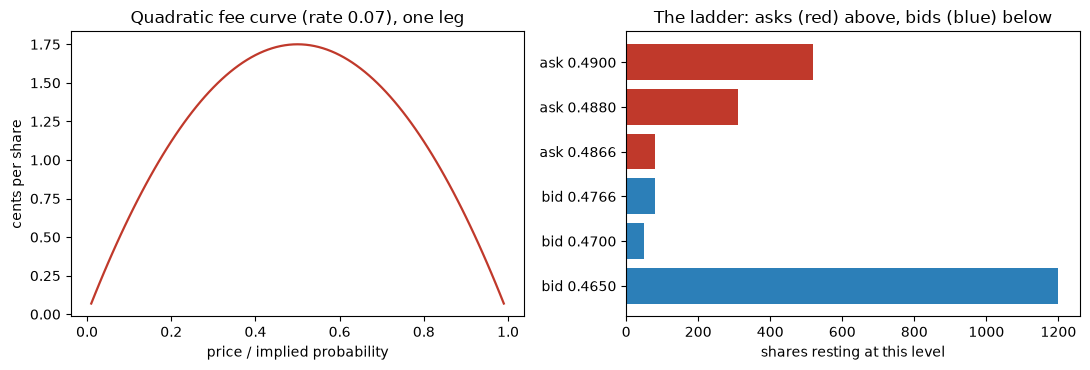

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
grid = [index / 100 for index in range(1, 100)]
axes[0].plot(grid, [FEE_RATE * p * (1 - p) * 100 for p in grid], color="#c0392b", lw=1.6)
axes[0].set_title(f"Quadratic fee curve (rate {FEE_RATE}), one leg")
axes[0].set_xlabel("price / implied probability")
axes[0].set_ylabel("cents per share")
axes[1].barh(
    [f"{row.side} {row.price:.4f}" for row in LADDER.itertuples()],
    [row.size for row in LADDER.itertuples()],
    color=["#c0392b" if row.side == "ask" else "#2c7fb8" for row in LADDER.itertuples()],
)
axes[1].invert_yaxis()
axes[1].set_title("The ladder: asks (red) above, bids (blue) below")
axes[1].set_xlabel("shares resting at this level")
fig.tight_layout()

---

# Part 2 — Writing a strategy, and four ways to trade it

Part 1 established what a trade costs. Part 2 writes a strategy from scratch and
then trades it four different ways, over a market small enough to print in its
entirety, so that every fill the engine produces can be checked against the
ladder it came from.

The strategy written here is the one used for the rest of the article, including
all of Part 3 on real books. It is deliberately the simplest trend-following
rule there is, because the subject of this article is the machinery around a
strategy rather than the strategy itself — and because a rule you can hold in
your head is one whose backtest you can check by hand. Replace its body with
your own idea and everything downstream keeps working.

The market is invented, deliberately. Fifteen book updates five minutes apart,
one instrument, three price levels on each side. YES resolves true. The mid
drifts from 0.51 up to 0.73 with three pullbacks in it, which is the shape that
separates a trend follower from a buy-and-hold.

## The canonical shape of market data

h5i-db's backtest engine reads a small set of canonical tables, and the one that
carries the book is `book_deltas`. Every row is one price level of one book
update; rows sharing an `event_index` form a single atomic event, and the last
row of the event is flagged with `is_last`. That structure is what lets the
replay loop know when a book is fully applied and safe to trade against.

| column | type | meaning |
|---|---|---|
| `ts_init` | `timestamp[ns]` | when your recorder received the update; this is what replay is ordered by |
| `ts_event` | `timestamp[ns]` | when the venue says it happened; keep both, they differ |
| `instrument_id` | `string` | the market |
| `outcome` | `uint16` | which token: 0 = YES, 1 = NO |
| `action` | `string` | `snapshot` for a full book, `delta` for an incremental change |
| `side` | `string` | `buy` is a bid, `sell` is an ask |
| `price` | `float64` | the level's price, as a probability |
| `size` | `float64` | shares resting at that level |
| `event_index` | `int64` | groups the rows of one atomic book update |
| `is_last` | `bool` | true on the final row of an event |
| `source_vendor` | `string` | provenance, so a mixed-source table stays auditable |

In [7]:
START = pd.Timestamp("2026-03-09T14:00:00Z")
STEP = pd.Timedelta(minutes=5)
MARKET = "RAIN-NYC-MAR10"
TICK = 0.01

# The mid at each update. It drifts from 0.51 to 0.73 with three pullbacks in it,
# which is the shape that separates a trend follower from a buy-and-hold.
MIDS = [0.51, 0.48, 0.45, 0.47, 0.52, 0.55, 0.51, 0.57, 0.54, 0.50,
        0.60, 0.58, 0.65, 0.70, 0.73]
#         ^ the dip: a patient bid at 0.46 gets hit here
# Displayed size at the touch on each side, which varies independently of price.
TOUCH_SIZES = [
    (800.0, 600.0), (700.0, 500.0), (900.0, 400.0), (500.0, 700.0), (600.0, 800.0),
    (700.0, 500.0), (900.0, 400.0), (600.0, 700.0), (800.0, 500.0), (900.0, 600.0),
    (700.0, 500.0), (600.0, 700.0), (800.0, 500.0), (900.0, 600.0), (850.0, 550.0),
]
DEPTH_LEVELS = 3

rows: dict[str, list] = {name: [] for name in cu.BOOK_DELTAS_SCHEMA.names}
stamps = []
for event_index, (mid_price, (bid_size, ask_size)) in enumerate(zip(MIDS, TOUCH_SIZES)):
    ts = (START + event_index * STEP).to_pydatetime()
    stamps.append(ts)
    # A two-tick spread around the mid, which is wide but keeps the arithmetic
    # legible: every round trip costs exactly one tick each way.
    bid, ask = round(mid_price - TICK, 4), round(mid_price + TICK, 4)
    # Deeper levels sit one tick further out with half again as much size, which
    # is a stylised but reasonable shape for an event book.
    levels = []
    for depth in range(DEPTH_LEVELS):
        levels.append(("buy", round(bid - depth * TICK, 4), bid_size * (1.5 ** depth)))
        levels.append(("sell", round(ask + depth * TICK, 4), ask_size * (1.5 ** depth)))
    for level_index, (side, price, size) in enumerate(levels):
        rows["ts_init"].append(ts)
        rows["ts_event"].append(ts)
        rows["instrument_id"].append(MARKET)
        rows["outcome"].append(0)  # 0 = YES
        rows["action"].append("snapshot")
        rows["side"].append(side)
        rows["price"].append(price)
        rows["size"].append(size)
        rows["event_index"].append(event_index + 1)
        rows["is_last"].append(level_index == len(levels) - 1)
        rows["source_vendor"].append("handmade-toy")

toy_book = pa.table(rows, schema=cu.BOOK_DELTAS_SCHEMA)
print(f"{toy_book.num_rows:,} rows x {toy_book.num_columns} columns "
      f"({len(MIDS)} events x {DEPTH_LEVELS * 2} levels)")
toy_book.to_pandas().head()

90 rows x 11 columns (15 events x 6 levels)


,ts_init,ts_event,instrument_id,outcome,action,side,price,size,event_index,is_last,source_vendor
0,2026-03-09 14:00:00,2026-03-09 14:00:00,RAIN-NYC-MAR10,0,snapshot,buy,0.50,800.0,1,False,handmade-toy
1,2026-03-09 14:00:00,2026-03-09 14:00:00,RAIN-NYC-MAR10,0,snapshot,sell,0.52,600.0,1,False,handmade-toy
2,2026-03-09 14:00:00,2026-03-09 14:00:00,RAIN-NYC-MAR10,0,snapshot,buy,0.49,1200.0,1,False,handmade-toy
3,2026-03-09 14:00:00,2026-03-09 14:00:00,RAIN-NYC-MAR10,0,snapshot,sell,0.53,900.0,1,False,handmade-toy
4,2026-03-09 14:00:00,2026-03-09 14:00:00,RAIN-NYC-MAR10,0,snapshot,buy,0.48,1800.0,1,False,handmade-toy


Drawn as the ladder from Part 1, the third book update — the dip — looks like
this. It is the same rows as above, arranged the way a trader reads them, with
each bar scaled to the size resting at that level.

The colours are semi-transparent overlays rather than solid fills, and the text
inherits its colour from the page, so the ladder reads correctly against a light
or a dark notebook theme without knowing which one it is in.

In [8]:
def ladder_html(book: pa.Table, event_index: int) -> HTML:
    """Draw one book event as a price ladder: asks above, bids below."""
    frame = book.to_pandas().query("event_index == @event_index")
    when = frame.ts_init.iloc[0]
    asks = frame[frame.side == "sell"].sort_values("price", ascending=False)
    bids = frame[frame.side == "buy"].sort_values("price", ascending=False)
    widest = frame["size"].max()
    spread = asks.price.min() - bids.price.max()

    def row(record, tint: str) -> str:
        width = record.size / widest * 100
        return (
            '<tr>'
            f'<td style="padding:2px 10px;opacity:.55;font-size:.85em">'
            f'{"ASK" if record.side == "sell" else "BID"}</td>'
            f'<td style="padding:2px 10px;text-align:right;font-variant-numeric:tabular-nums">'
            f'{record.price:.4f}</td>'
            f'<td style="padding:2px 10px;text-align:right;opacity:.7;'
            f'font-variant-numeric:tabular-nums">{record.size:,.0f}</td>'
            f'<td style="padding:2px 10px;width:55%">'
            f'<div style="background:{tint};width:{width:.1f}%;height:14px;'
            'border-radius:3px"></div></td>'
            '</tr>'
        )

    body = "".join(row(record, "rgba(192,57,43,.55)") for record in asks.itertuples())
    body += (
        '<tr><td colspan="4" style="padding:6px 10px;border-top:1px dashed '
        'currentColor;border-bottom:1px dashed currentColor;opacity:.65;'
        f'font-size:.85em">spread {spread:.4f} &nbsp;·&nbsp; mid '
        f'{(asks.price.min() + bids.price.max()) / 2:.4f} &nbsp;·&nbsp; '
        'nothing trades in here</td></tr>'
    )
    body += "".join(row(record, "rgba(44,127,184,.55)") for record in bids.itertuples())
    return HTML(
        '<div style="font-family:ui-monospace,SFMono-Regular,Menlo,monospace;'
        'max-width:620px">'
        f'<div style="padding:4px 10px;opacity:.75;font-size:.9em">{MARKET}'
        f' &nbsp;·&nbsp; YES book at {when:%H:%M:%S}</div>'
        f'<table style="border-collapse:collapse;width:100%">{body}</table></div>'
    )


ladder_html(toy_book, 3)

## Two more tables: what the instrument is, and how it ended

The book alone does not say what happens at the end. Two more canonical tables
carry that: `instruments` describes the contract and `resolutions` records the
outcome. `venues.MarketSpec` writes both from one declaration, which matters
because the pairing of outcome labels to token identifiers is positional and
getting it backwards would attribute every fill to the wrong side.

Two fields on the spec do real work later:

- `expiration_ns` is when the contract stops trading. Orders arriving after it
  are rejected rather than filled, which is the correct behaviour and one you
  want enforced rather than remembered.
- `settlement_observable_ns` is when the outcome became *knowable*. The engine
  refuses to settle a position unless the replay actually reached that instant,
  so a backtest cannot quietly mark a position to an outcome that had not been
  published yet. This is the single most common source of accidental lookahead
  in prediction-market research and it is worth having a machine enforce it.

In [9]:
last_ns = int(pd.Timestamp(stamps[-1]).value)
toy_spec = venues.MarketSpec(
    instrument_id=MARKET,
    venue="polymarket",
    outcome_labels=("YES", "NO"),
    tokens=("token-yes-toy", "token-no-toy"),
    tick_size=TICK,
    lot_size=1.0,
    expiration_ns=last_ns,
    settlement_observable_ns=last_ns,
    winner_outcome=0,  # index into outcome_labels: YES wins
    metadata={"question": "Will NYC record measurable rain on 2026-03-10?"},
)

db = h5i_db.Database(cu.fresh_db("article_polymarket_toy"), create=True)
written = venues.write_markets(db, [toy_spec], note="toy market definition")
db.create_table("book_deltas", toy_book.schema, time_column="ts_init")
db.append("book_deltas", toy_book, note="14 book updates, 3 levels a side")
db.snapshot("toy-v1", tables=["instruments", "book_deltas", "resolutions"],
            note="the pinned input for every toy run")
print(written)
print("\ninstruments (one row per tradeable outcome):")
print(db.read("instruments").to_pandas().to_string(index=False))
print("\nresolutions (kind = winner | split | void):")
print(db.read("resolutions").to_pandas().to_string(index=False))

IngestReport(vendor='markets', instruments=2 resolutions=1, coverage=n/a, gaps=0, replayed=False)

instruments (one row per tradeable outcome):
   ts_init  instrument_id      venue              kind  outcome outcome_label  tick_size  lot_size       expiration_ns  settlement_observable_ns  neg_risk
1970-01-01 RAIN-NYC-MAR10 polymarket prediction_market        0           YES       0.01       1.0 1773069000000000000       1773069000000000000     False
1970-01-01 RAIN-NYC-MAR10 polymarket prediction_market        1            NO       0.01       1.0 1773069000000000000       1773069000000000000     False

resolutions (kind = winner | split | void):
            ts_init  instrument_id   kind  outcome  payout  outcome_count
2026-03-09 15:10:00 RAIN-NYC-MAR10 winner        0     NaN            NaN


`db.snapshot(...)` is the reason the four runs below are comparable. It pins a
named, immutable view of the input tables, so every strategy provably reads the
same bytes and the only thing varying between runs is the strategy itself. If
you later append more data, the snapshot still resolves to what it always did.

## The quote panel

Strategies do not read `book_deltas` directly. They read a **quote panel**: one
row per instrument per instant, carrying the best price and displayed size on
each side. Collapsing a book to its touch is a `row_number()` window — rank
each side by price, best first, and keep rank one.

The `CASE` in the `ORDER BY` is the only subtle part, and it encodes the
asymmetry from Part 1: the best bid is the *highest* buy price, while the best
ask is the *lowest* sell price. Getting that backwards quietly hands every
strategy the worst price in the book instead of the best one, which is a bug
that produces plausible-looking output rather than an error.

| column | type | meaning |
|---|---|---|
| `ts` | `timestamp[ns]` | the instant this book was current |
| `instrument_id` | `string` | the market |
| `bid` / `ask` | `float64` | best prices on each side |
| `bid_size` / `ask_size` | `float64` | displayed depth at the touch |

In [10]:
TOP_OF_BOOK = """
WITH ranked AS (
    SELECT instrument_id, ts_init AS ts, side, price, size,
           row_number() OVER (
               PARTITION BY instrument_id, ts_init, side
               ORDER BY CASE WHEN side = 'buy' THEN -price ELSE price END
           ) AS depth_rank
    FROM h5i('book_deltas', 'toy-v1')
    WHERE outcome = 0
)
SELECT instrument_id, ts,
       max(CASE WHEN side = 'buy'  THEN price END) AS bid,
       max(CASE WHEN side = 'sell' THEN price END) AS ask,
       max(CASE WHEN side = 'buy'  THEN size  END) AS bid_size,
       max(CASE WHEN side = 'sell' THEN size  END) AS ask_size
FROM ranked
WHERE depth_rank = 1
GROUP BY instrument_id, ts
ORDER BY instrument_id, ts
"""
toy_panel = db.sql(TOP_OF_BOOK).to_pandas()
toy_panel["mid"] = (toy_panel.bid + toy_panel.ask) / 2
print(f"{len(toy_panel)} rows x {toy_panel.shape[1]} columns")
toy_panel.head()

15 rows x 7 columns


,instrument_id,ts,bid,ask,bid_size,ask_size,mid
0,RAIN-NYC-MAR10,2026-03-09 14:00:00,0.50,0.52,800.0,600.0,0.51
1,RAIN-NYC-MAR10,2026-03-09 14:05:00,0.47,0.49,700.0,500.0,0.48
2,RAIN-NYC-MAR10,2026-03-09 14:10:00,0.44,0.46,900.0,400.0,0.45
3,RAIN-NYC-MAR10,2026-03-09 14:15:00,0.46,0.48,500.0,700.0,0.47
4,RAIN-NYC-MAR10,2026-03-09 14:20:00,0.51,0.53,600.0,800.0,0.52


`h5i('book_deltas', 'toy-v1')` in the `FROM` clause is how a query reads a
pinned snapshot rather than the live table, so this panel is derived from
exactly the bytes the backtests will replay.

h5i-db also ships `backtest.quote_panel`, which is the convenience version of
this query and what Part 3 uses. It assumes one level per side, which is true
of the real capture there because the ingest truncates to top of book, and is
not true of this toy book — hence the explicit query here.

## The one timing rule that matters

Before the strategies, the single most important mechanical fact about this
engine, because it silently removes the most common bug in homemade backtests.

**An order stamped after a book update does not trade against that update. It
trades against the next one.**

The reasoning is that market data reaches the venue before the strategy sees it,
and strategy commands are queued rather than executed inside the callback that
produced them. So an intent decided from the 14:00 book is released into a queue
and meets the book the venue processes next, at 14:05. You never get to trade at
the price that caused you to trade — which is exactly the constraint reality
imposes and exactly the one a naive `df.shift(-1)` backtest forgets.

The demonstration below stamps the same buy at three different instants inside
the same five-minute gap and shows all three receiving the same fill.

In [11]:
MICRO = dt.timedelta(microseconds=1)


def run_toy(name: str, intents: list[dict], **execution) -> backtest.BacktestResult:
    """Append a signals table and replay it against the pinned toy snapshot."""
    table = backtest.signal_table(intents)
    signal_table = f"signals_{name}"
    db.create_table(signal_table, table.schema, time_column="ts")
    db.append(signal_table, table)
    return backtest.execute(
        db,
        backtest.BacktestConfig(
            run_id=name,
            data=backtest.DataConfig(signals=signal_table, snapshot="toy-v1"),
            portfolio=backtest.PortfolioConfig(starting_cash=10_000.0),
            execution=backtest.ExecutionConfig(**execution),
            output=backtest.OutputConfig(equity_interval_nanos=60 * 1_000_000_000),
        ),
    )


timing = []
probes = {
    "one microsecond after 14:00": stamps[0] + MICRO,
    "midway, at 14:02:30": stamps[0] + dt.timedelta(minutes=2, seconds=30),
    "one microsecond before 14:05": stamps[1] - MICRO,
}
for index, (label, when) in enumerate(probes.items()):
    result = run_toy(
        f"timing{index}",
        [{"ts": when, "instrument_id": MARKET, "outcome": 0, "side": "buy", "quantity": 100.0}],
    )
    fill = result.fills.to_pandas().iloc[0]
    timing.append({"decided at": label, "filled at": fill.ts, "price": fill.price})
print(f"the 14:00 book quoted {toy_panel.ask.iloc[0]:.2f} on the ask, "
      f"the 14:05 book quoted {toy_panel.ask.iloc[1]:.2f}\n")
print(pd.DataFrame(timing).to_string(index=False))

the 14:00 book quoted 0.52 on the ask, the 14:05 book quoted 0.49

                  decided at           filled at  price
 one microsecond after 14:00 2026-03-09 14:05:00   0.49
         midway, at 14:02:30 2026-03-09 14:05:00   0.49
one microsecond before 14:05 2026-03-09 14:05:00   0.49


All three fill at 0.49, the ask of the *following* book, and all three are
recorded at 14:05. The engine will not let you buy at the 0.52 you were looking
at when you decided. Every signal generator in h5i-db stamps its orders one
microsecond after the quote they were derived from for exactly this reason.

## Writing a strategy

h5i-db ships reference implementations of a dozen standard rules, and it would
be quicker to call one. We are going to write ours instead, because the point of
this article is the machinery around a strategy rather than the strategy, and
the only way to make that machinery yours is to see where your own code plugs
into it. Everything from here to the end of the article runs on the function
below; swap its body and the rest still works.

The rule is **breakout**, about the simplest trend-following idea there is:

> Buy when the price makes a new high for the last `lookback` samples. Sell out
> when it makes a new low for the last `lookback` samples. Hold nothing
> otherwise.

### A strategy is a table, not a callback

The important design decision is what a strategy *is* here. It is not an object
with an `on_tick` method. It is a function that reads a quote panel and returns
a **signals table** — a list of timestamped order intents, which is data.

That has a practical consequence worth stating plainly: a table has a content
hash, so a run can be identified by its inputs, reproduced exactly, deduplicated
against an earlier identical run, and compared with another. A Python closure
has none of those properties. The cost is that a signals table cannot react to
its own fills — it is decided in advance — which is fine for this rule and not
fine for, say, a position-sizing rule that depends on current inventory.

| column | type | meaning |
|---|---|---|
| `ts` | `timestamp[ns]` | when the order is released |
| `instrument_id` | `string` | the market |
| `outcome` | `uint16` | 0 = YES |
| `side` | `string` | `buy` or `sell` |
| `quantity` | `float64` | shares requested, not necessarily shares filled |
| `kind` | `string` | `market` or `limit` |
| `limit_price` | `float64` | the worst acceptable price, for limit orders |
| `time_in_force` | `string` | `ioc` fills now or cancels; `gtc` rests until filled |
| `post_only` | `bool` | refuse to execute as a taker, i.e. insist on being a maker |
| `reduce_only` | `bool` | only allowed to shrink a position, never to open one |

### Four things that are easy to get wrong

The function is fifteen lines and four of them are load-bearing. Each one is a
bug that produces plausible output rather than an error, which is the kind worth
knowing about in advance.

**`mid.shift(1)` before the rolling window.** The window has to describe the
*prior* `lookback` samples. Without the shift, the current price is compared
against a window that already contains it, so `now > prior_high` can never be
true and the rule silently never trades.

**`ts + SUBMIT_DELAY` on every stamp.** From the timing section above: an order
must be stamped strictly after the quote it was decided from. Stamp it *at* the
quote and it may match the book you were reacting to, which is a backtest that
trades on information it did not have.

**The `holding` flag.** Signals are stateless data, so any state the rule needs
lives in the generator. Without it the rule emits a buy on every new high, and
a position that was supposed to be one contract becomes forty.

**Sorting before returning.** We walk instrument by instrument, so the rows come
out grouped by market rather than by time. `db.append` enforces the table's sort
key and will reject the batch outright — one of the few mistakes here that does
fail loudly.

In [12]:
SUBMIT_DELAY = dt.timedelta(microseconds=1)


def breakout_signals(panel, *, lookback=24, quantity=10.0, outcome=0):
    """Buy a new `lookback`-sample high; sell out on a new `lookback`-sample low."""
    rows = []
    for instrument_id, frame in panel.groupby("instrument_id", sort=True):
        frame = frame.sort_values("ts")
        mid = (frame["bid"] + frame["ask"]) / 2.0
        # shift(1) so the window is the PRIOR lookback samples, excluding now.
        prior_high = mid.shift(1).rolling(lookback).max()
        prior_low = mid.shift(1).rolling(lookback).min()
        holding = False
        for ts, now, high, low in zip(frame["ts"], mid, prior_high, prior_low):
            if pd.isna(high) or pd.isna(low):
                continue  # still filling the warm-up window
            if not holding and now > high:
                rows.append({"ts": ts + SUBMIT_DELAY, "instrument_id": instrument_id,
                             "outcome": outcome, "side": "buy", "quantity": quantity,
                             "tag": "breakout-entry"})
                holding = True
            elif holding and now < low:
                rows.append({"ts": ts + SUBMIT_DELAY, "instrument_id": instrument_id,
                             "outcome": outcome, "side": "sell", "quantity": quantity,
                             "reduce_only": True, "tag": "breakout-exit"})
                holding = False
    # append() enforces the sort key, so put the rows back in global time order.
    rows.sort(key=lambda row: row["ts"])
    return rows


toy_signals = breakout_signals(toy_panel, lookback=2, quantity=100.0)
signal_rows = backtest.signal_table(toy_signals)
print(f"{len(toy_signals)} signals from {len(toy_panel)} quotes\n")
signal_rows.to_pandas()[["ts", "side", "quantity", "kind", "reduce_only", "tag"]]

5 signals from 15 quotes



,ts,side,quantity,kind,reduce_only,tag
0,2026-03-09 14:20:00.000001024,buy,100.0,market,False,breakout-entry
1,2026-03-09 14:30:00.000001024,sell,100.0,market,True,breakout-exit
2,2026-03-09 14:35:00.000001024,buy,100.0,market,False,breakout-entry
3,2026-03-09 14:45:00.000001024,sell,100.0,market,True,breakout-exit
4,2026-03-09 14:50:00.000001024,buy,100.0,market,False,breakout-entry


Five signals: two complete round trips and a third entry left open at the end.
`reduce_only=True` on the exits is worth a word — it tells the engine the order
may only shrink a position and never open one, so a stray exit signal with no
position behind it is refused rather than quietly going short.

### Checking it against the reference

`breakout` is one of the rules h5i-db ships, which makes it a free test: if the
reimplementation is right, it should produce exactly the same signals. This is
worth doing whenever you can, because the failure modes above are all silent.

In [13]:
reference = backtest.STRATEGIES["breakout"](toy_panel, lookback=2, quantity=100.0)
mine = signal_rows.to_pandas()
theirs = reference.signals.to_pandas()
identical = (
    set(zip(mine.ts.dt.floor("us"), mine.side, mine.quantity))
    == set(zip(theirs.ts.dt.floor("us"), theirs.side, theirs.quantity))
)
print(f"ours     {len(mine)} signals: {list(mine.side)}")
print(f"shipped  {len(theirs)} signals: {list(theirs.side)}")
print(f"identical: {identical}")

ours     5 signals: ['buy', 'sell', 'buy', 'sell', 'buy']
shipped  5 signals: ['buy', 'sell', 'buy', 'sell', 'buy']
identical: True


## Four ways to trade the same signals

The signals table is now fixed. What follows varies only *how the orders are
sent*, which is the whole argument of Part 2.

**Taker breakout.** The signals as written: market orders, crossing the spread
whenever the rule fires.

**Buy and hold.** One market buy at the start, then nothing. No exit, so the
position is still open when the market resolves and it settles at \$1.00 a
share. This is the fewest round trips possible, so the lowest cost, and its P&L
is entirely about the forecast rather than the execution.

**Patient maker.** A limit buy at 0.46 posted at the start with
`time_in_force="gtc"` and `post_only=True`. It does not cross the spread; it
waits at 0.46 for the market to come to it, which it does during the dip at
14:10. `post_only` is what makes the fill a maker fill: the engine marks it
`is_taker=False`, so on a fee-charging venue it would pay the maker rate or earn
a rebate rather than paying the taker fee.

**Delayed taker.** The breakout signals again, byte for byte, with ten minutes
of latency configured, meaning every order reaches the venue ten minutes after
the decision that produced it. Latency is an execution setting rather than a
strategy setting, so this is the identical signals table under a different
`ExecutionConfig` — precisely the comparison you want to be able to make
cheaply.

In [14]:
db.create_table("signals_breakout", signal_rows.schema, time_column="ts")
db.append("signals_breakout", signal_rows)


def execute_toy(run_id: str, signals: str, **execution) -> backtest.BacktestResult:
    return backtest.execute(
        db,
        backtest.BacktestConfig(
            run_id=run_id,
            data=backtest.DataConfig(signals=signals, snapshot="toy-v1"),
            portfolio=backtest.PortfolioConfig(starting_cash=10_000.0),
            execution=backtest.ExecutionConfig(**execution),
            output=backtest.OutputConfig(equity_interval_nanos=60 * 1_000_000_000),
            metadata={"strategy": "breakout", "lookback": 2},
        ),
    )


runs = {
    "1. taker breakout": execute_toy("toy-breakout", "signals_breakout"),
    "2. buy and hold": run_toy(
        "hold",
        [{"ts": stamps[0] + MICRO, "instrument_id": MARKET, "outcome": 0,
          "side": "buy", "quantity": 100.0, "tag": "entry"}],
    ),
    "3. patient maker": run_toy(
        "maker",
        [{"ts": stamps[0] + MICRO, "instrument_id": MARKET, "outcome": 0,
          "side": "buy", "quantity": 100.0, "kind": "limit", "limit_price": 0.46,
          "time_in_force": "gtc", "post_only": True, "tag": "rest-at-46"}],
    ),
    "4. taker, 10 min late": execute_toy(
        "toy-breakout-late", "signals_breakout", latency_nanos=10 * 60 * 1_000_000_000
    ),
}

def summarise(label: str, result: backtest.BacktestResult) -> dict:
    """Read the run's own result tables rather than trusting a summary dict.

    `realized_pnl` covers positions the strategy closed itself; `settlement_pnl`
    covers positions still open when the market resolved. A strategy that never
    exits earns all of its money in the second column, so both are needed before
    two strategies can be compared at all.
    """
    positions = result.positions.to_pandas()
    orders = result.orders.to_pandas()
    realized = float(result.summary()["realized_pnl"])
    settlement = float(positions.settlement_pnl.fillna(0).sum()) if len(positions) else 0.0
    return {
        "strategy": label,
        "orders": len(orders),
        "fills": len(result.fills.to_pandas()),
        "realized_pnl": realized,
        "settlement_pnl": settlement,
        "total_pnl": realized + settlement,
    }


scoreboard = pd.DataFrame([summarise(label, result) for label, result in runs.items()])
print("100 shares a trade, zero fees, identical book and identical outcome:\n")
print(scoreboard.round(2).to_string(index=False))

100 shares a trade, zero fees, identical book and identical outcome:

             strategy  orders  fills  realized_pnl  settlement_pnl  total_pnl
    1. taker breakout       5      5           4.0            41.0       45.0
      2. buy and hold       1      1           0.0            51.0       51.0
     3. patient maker       1      1           0.0            54.0       54.0
4. taker, 10 min late       5      5          -6.0            29.0       23.0


Four ways of trading, one book, one outcome, and a spread of results that has
almost nothing to do with forecasting. All four were right about the direction —
the mid went from 0.51 to 0.73 and the market then resolved YES — and the best
finishes with more than double the profit of the worst. Two of them are running
*the same signals table*, differing only in latency.

Note also which column each strategy earned its money in. The two that never
sold have zero `realized_pnl` and all of their profit in `settlement_pnl`,
because they were still holding when the market resolved. Comparing strategies
on realized P&L alone would have scored buy-and-hold at exactly zero.

The fills explain the rest completely. Here is every execution the engine
produced, for every run.

In [15]:
for label, result in runs.items():
    fills = result.fills.to_pandas()
    if fills.empty:
        print(f"\n{label}: no fills\n")
        continue
    view = fills[["ts", "side", "price", "quantity", "commission", "is_taker", "tag"]]
    print(f"\n{label}  ({len(fills)} fills)")
    print(view.to_string(index=False))


1. taker breakout  (5 fills)
                 ts side  price  quantity  commission  is_taker            tag
2026-03-09 14:25:00  buy   0.56     100.0         0.0      True breakout-entry
2026-03-09 14:35:00 sell   0.56     100.0         0.0      True  breakout-exit
2026-03-09 14:40:00  buy   0.55     100.0         0.0      True breakout-entry
2026-03-09 14:50:00 sell   0.59     100.0         0.0      True  breakout-exit
2026-03-09 14:55:00  buy   0.59     100.0         0.0      True breakout-entry

2. buy and hold  (1 fills)
                 ts side  price  quantity  commission  is_taker   tag
2026-03-09 14:05:00  buy   0.49     100.0         0.0      True entry

3. patient maker  (1 fills)
                 ts side  price  quantity  commission  is_taker        tag
2026-03-09 14:10:00  buy   0.46     100.0         0.0     False rest-at-46

4. taker, 10 min late  (5 fills)
                 ts side  price  quantity  commission  is_taker            tag
2026-03-09 14:35:00  buy   0.58     

Read the entry prices against each other, because that is where the difference
lives. Buy-and-hold entered once at 0.49. The patient maker entered at 0.46,
three cents better, because it refused to cross the spread and was rewarded for
waiting.

The breakout rule bought at 0.56, then 0.55, then 0.59, and this is not bad luck
— it is the rule working as designed. A breakout fires *after* a move, and by
then the move has already happened and the ask has already risen. Reacting to
price means paying for the reaction. Look at its first round trip in particular:
bought at 0.56, sold at 0.56, zero gross profit, and the only thing that changed
hands was the spread.

The delayed run is the clearest of the four. Identical signals, ten minutes
later, in a market moving a couple of cents per five-minute update, and the same
rule's round trips go from `+4` to `-6`. Nothing about the strategy changed. A
ten-minute lag turned a correct call into a losing one.

The comparison worth making explicit is entry price against final value, because
it isolates execution from forecasting.

In [16]:
comparison = []
for label, result in runs.items():
    fills = result.fills.to_pandas()
    if fills.empty:
        continue
    buys = fills[fills.side == "buy"]
    comparison.append(
        {
            "strategy": label,
            "buys": len(buys),
            "avg_buy_price": float((buys.price * buys.quantity).sum() / buys.quantity.sum()),
            "shares_bought": float(buys.quantity.sum()),
            "shares_sold": float(fills[fills.side == "sell"].quantity.sum()),
        }
    )
detail = pd.DataFrame(comparison)
detail["cents_worse_than_best_entry"] = (detail.avg_buy_price - detail.avg_buy_price.min()) * 100
print(detail.round(3).to_string(index=False))
print("\nevery run bought the same asset, which settled at $1.00 per share")

print("\norders that did not fill:")
for label, result in runs.items():
    orders = result.orders.to_pandas()
    unfilled = orders[orders.status != "filled"]
    for row in unfilled.itertuples():
        print(f"  {label:<22} {row.ts}  {row.side:<4} {row.status}"
              f"{'  ' + str(row.reject_reason)[:60] if isinstance(row.reject_reason, str) else ''}")
if not any((result.orders.to_pandas().status != "filled").any() for result in runs.values()):
    print("  none: every order in every run filled in full")

             strategy  buys  avg_buy_price  shares_bought  shares_sold  cents_worse_than_best_entry
    1. taker breakout     3          0.567          300.0        200.0                       10.667
      2. buy and hold     1          0.490          100.0          0.0                        3.000
     3. patient maker     1          0.460          100.0          0.0                        0.000
4. taker, 10 min late     3          0.633          300.0        200.0                       17.333

every run bought the same asset, which settled at $1.00 per share

orders that did not fill:
  none: every order in every run filled in full


## What the maker gave up

The patient maker looks unambiguously best in the table above, and on this path
it was. That conclusion is not general, and the reason is worth stating plainly
because it is where maker strategies actually fail: a resting order that the
market never reaches simply does not trade.

Re-run the same strategy with the limit two cents lower, at 0.44, in a book
whose ask never fell below 0.46.

In [17]:
missed = run_toy(
    "maker-too-low",
    [{"ts": stamps[0] + MICRO, "instrument_id": MARKET, "outcome": 0, "side": "buy",
      "quantity": 100.0, "kind": "limit", "limit_price": 0.44,
      "time_in_force": "gtc", "post_only": True, "tag": "rest-at-44"}],
)
print(missed.orders.to_pandas()[
    ["ts", "side", "kind", "limit_price", "quantity", "filled", "status", "reject_reason"]
].to_string(index=False))
print(f"\nfills: {len(missed.fills.to_pandas())}, "
      f"total P&L: {missed.summary()['realized_pnl']:.2f}")
for warning in missed.summary()["warnings"] or []:
    print(f"warning: {warning}")

                 ts side  kind  limit_price  quantity  filled    status                                         reject_reason
2026-03-09 14:05:00  buy limit         0.44     100.0     0.0 cancelled RAIN-NYC-MAR10 stopped trading at 1773069000000000000

fills: 0, total P&L: 0.00


Two cents of greed cost the entire position, and the engine reports it as a
cancelled order with a stated reason rather than as a fill that never happened.
That asymmetry — takers pay a known cost with certainty, makers pay an unknown
cost with probability — is the real trade-off, and it is why the maker/taker
choice deserves to be a variable in your research rather than an assumption
baked into it.

One honest caveat on the maker result. This book is a periodic *snapshot*, not
a stream of every individual change, so the engine can tell you that the ask
reached your price but cannot tell you whether you were at the front of the
queue when it did. It fills you optimistically. Modelling queue position
properly needs every book delta between snapshots, and h5i-db will refuse a
`queue_position=True` configuration on snapshot data rather than return a
plausible-looking number — which is the behaviour you want from a backtester.

In [18]:
try:
    backtest.execute(
        db,
        backtest.BacktestConfig(
            run_id="queue-claim",
            data=backtest.DataConfig(signals="signals_breakout", snapshot="toy-v1"),
            portfolio=backtest.PortfolioConfig(starting_cash=10_000.0),
            execution=backtest.ExecutionConfig(queue_position=True),
        ),
    )
except ValueError as error:
    print(f"refused: {str(error)[:220]}")

refused: backtest preflight failed: unsupported_queue_claim: queue-position replay is not defensible with snapshot_l2 inputs


## Adding the fee back

Finally, the same breakout signals under three fee regimes. The signals table
does not change; only the `ExecutionConfig` does. This is the sensitivity that
tells you whether a rule is fragile to a cost assumption, and it takes three
lines to run.

Worth knowing while reading the output: re-executing a configuration that has
already run against the same pin returns the *recorded* result rather than
replaying it. The zero-fee row below is therefore the identical run from the
scoreboard, served from the trial ledger, which is a property of the pinning
rather than a coincidence.

In [19]:
fee_rows = []
for label, execution in {
    "Polymarket (no fee)": {},
    "quadratic fee, rate 0.02": {"fee_kind": "kalshi", "fee_rate": 0.02},
    "quadratic fee, rate 0.07": {"fee_kind": "kalshi", "fee_rate": FEE_RATE},
}.items():
    result = execute_toy(f"toy-fee-{len(fee_rows)}", "signals_breakout", **execution)
    row = summarise(label, result)
    row["commissions"] = float(result.fills.to_pandas().commission.sum())
    fee_rows.append(row)
fees = pd.DataFrame(fee_rows).rename(columns={"strategy": "fee regime"})
print(fees[["fee regime", "fills", "commissions", "realized_pnl", "total_pnl"]]
      .round(2).to_string(index=False))

              fee regime  fills  commissions  realized_pnl  total_pnl
     Polymarket (no fee)      5         0.00          4.00      45.00
quadratic fee, rate 0.02      5         2.48          1.52      42.52
quadratic fee, rate 0.07      5         8.60         -4.60      36.40


## Part 2, in one line

Same book, same outcome, same direction called correctly by all four, and the
best result is about double the worst — on nothing but how the orders were sent.
A backtest that does not model entry price, exit price, latency and fill
probability is not measuring the strategy. It is measuring the price path, which
you already knew.

It is worth being clear about what this toy does *not* establish. Buy-and-hold
wins here because this particular path went up and resolved YES, and a path that
went the other way would have made it the worst of the four. What generalises is
not the ranking; it is the size of the gap that execution alone opens up between
strategies with identical views.

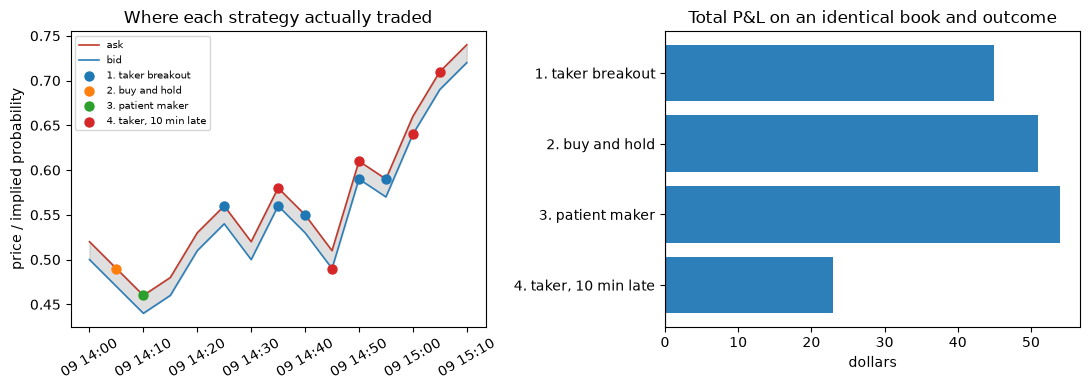

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(toy_panel.ts, toy_panel.ask, color="#c0392b", lw=1.2, label="ask")
axes[0].plot(toy_panel.ts, toy_panel.bid, color="#2c7fb8", lw=1.2, label="bid")
axes[0].fill_between(toy_panel.ts, toy_panel.bid, toy_panel.ask, color="grey", alpha=0.25)
for label, result in runs.items():
    fills = result.fills.to_pandas()
    if fills.empty:
        continue
    axes[0].scatter(fills.ts, fills.price, s=42, zorder=3, label=label)
axes[0].set_title("Where each strategy actually traded")
axes[0].set_ylabel("price / implied probability")
axes[0].tick_params(axis="x", labelrotation=30)
axes[0].legend(fontsize=7)
axes[1].barh(scoreboard.strategy, scoreboard.total_pnl,
             color=["#2c7fb8" if value >= 0 else "#c0392b" for value in scoreboard.total_pnl])
axes[1].axvline(0.0, color="black", lw=0.8)
axes[1].invert_yaxis()
axes[1].set_title("Total P&L on an identical book and outcome")
axes[1].set_xlabel("dollars")
fig.tight_layout()

## The whole run as one page

Everything above was assembled by hand: a scoreboard here, a fills table there,
a chart at the end. `result.report()` does that in one call, rendering the run
as a single self-contained HTML document — no network access when it is opened,
no dependencies, so it can be attached to a review, committed next to the run,
or opened in five years.

It is not a tearsheet, and the ordering says so. A tearsheet answers *how did
the equity curve behave*; this answers *should I believe these numbers, and what
actually happened*, so it leads with the evidence:

- a **status banner** naming the replay fidelity, because a periodic snapshot
  cannot support the claims a full tick book can, and whether the run was
  pinned;
- **provenance** — the run digest, the config digest and the snapshot the data
  came from;
- then the **performance** panels;
- then the **execution record**: the order lifecycle with rejection reasons in
  the engine's own words, and every fill plotted and tabled;
- and finally the **configuration verbatim**, so the page carries everything
  needed to re-run what it describes.

The delayed taker is the one worth reporting on, because it is the run whose
numbers most need explaining: identical signals to the first run, a worse result,
and the reason visible only in where the fills landed on the book.

In [21]:
report_path = Path("data/cache/toy-delayed-taker-report.html")
document = runs["4. taker, 10 min late"].report(
    report_path, title="Toy market: taker breakout with 10 minutes of latency"
)
print(f"wrote {report_path} ({len(document) / 1024:.0f} KB, self-contained)")

wrote data/cache/toy-delayed-taker-report.html (38 KB, self-contained)


To show it inline, `display()` the result itself: `_repr_html_` wraps the page
in an `<iframe srcdoc="...">`, which is worth understanding rather than taking
on faith, because it is the one thing about the report you cannot change.

The obvious approach — `display(HTML(document))`, injecting the markup straight
into the notebook — does not work here, for two reasons. The report is a whole
document with its own dark theme, so its `<style>` would repaint the notebook
around it. More fundamentally, the page renders itself: its `<body>` is an empty
container a few dozen characters long, and a single script builds every chart
and table from an embedded JSON payload. Notebook front ends do not execute
scripts in HTML output, so a direct injection would produce an empty box.

An iframe with `srcdoc` is a separate browsing context, which both isolates the
styles and lets the script run. The cost is that escaping the document into an
attribute inflates it by roughly half, which is why this notebook is larger than
the recipes it is drawn from.

In [22]:
# The claim above, checked rather than asserted: strip the scripts out of the
# document and see what markup is left for a front end to render.
import re

body = re.search(r"<body[^>]*>(.*)</body>", document, re.S).group(1)
static = re.sub(r"<script.*?</script>", "", body, flags=re.S).strip()
print(f"whole document   {len(document):,} chars")
print(f"body             {len(body):,} chars")
print(f"body less script {len(static):,} chars  ->  {static}")

display(runs["4. taker, 10 min late"])

whole document   38,983 chars
body             32,382 chars
body less script 59 chars  ->  <main id="app"></main>
<div class="tooltip" id="tip"></div>


{'run_id': 'toy-breakout-late',
 'fork': 'bt-toy-breakout-late',
 'digest': '60c1f938eb9a88968adc93b5af88a26cab58a0600f281faf00393d1f23a10031',
 'starting_cash': 10000.0,
 'final_cash': 9923.0,
 'realized_pnl': -6.0,
 'commissions': 0.0,
 'funding_paid': 0.0,
 'fills': 5,
 'orders': 5,
 'records_processed': 15,
 'simulated_through_ns': 1773069000000000000,
 'equity_points': 15,
 'settlement_applied': True,
 'coverage': None,
 'liquidations': 0,
 'rejected_for_margin': 0,
 'self_trades_prevented': 0,
 'calibration_samples': [],
 'set_operations': [],
 'forecasts': 0,
 'mark_points': 15,
 'expirations': [{'instrument_id': 'RAIN-NYC-MAR10',
   'ts': 1773069000000000000}],
 'metrics': {'orders_submitted': 5,
  'orders_filled': 5,
  'orders_cancelled_unfilled': 0,
  'orders_rejected_margin': 0,
  'orders_rejected_risk': 0,
  'orders_rejected_self_trade': 0,
  'orders_rejected_naked_short': 0,
  'orders_rejected_expired': 0,
  'orders_rejected_post_only': 0,
  'orders_triggered': 0,
  'twap_slices': 0,
  'fills_taker': 5,
  'fills_maker': 0,
  'book_gaps': 0,
  'liquidations': 0,
  'set_operations': 0,
  'set_operations_rejected': 0,
  'instruments_expired': 1},
 'warnings': [],
 'cached': False,
 'trial_digest': '6d7c45908ed21833fc95b0ee096cea7aecca1ffb5bf187991e17046ebc8c91e1'}

In [23]:
db.close()

---

# Part 3 — The same strategy on real Polymarket books

The toy proves the plumbing and nothing about the world. Part 3 takes the same
`breakout_signals` function — unchanged, not one line different — and runs it
over real tick-level Polymarket order books, real markets, and real UMA-verified
resolutions, to ask the only question that matters: **does it survive real
costs?**

The answer turns out to be interesting rather than a flat no, and getting to it
involves every mistake this kind of research invites: a parameter search that
inflates its own winner, a result that evaporates when the window is cut in
half, and a settlement gate that would have manufactured a spectacular profit if
the engine had let it.

## The data

A bounded, non-commercial sample of tick-level Polymarket books, published on
Kaggle. It is not redistributed with this article; the cell below prints the
download commands if the files are absent. The dataset is CC BY-NC 4.0, so
review the licence before using anything derived from it commercially.

If you would rather work with live data than a capture, the cookbook ships
`scripts/fetch_polymarket.py`, which pulls market definitions and current books
straight from Polymarket's public read-only endpoints into the same layout the
ingest path reads. Be aware of what that path can and cannot give you: the API
serves *current* books for live markets and historical *mid points* for any
market, but not historical depth. A study of execution quality needs an archive
for that reason, which is why this part uses a capture.

In [24]:
CACHE = Path("data/cache/kaggle-polymarket")
missing = cu.kaggle_missing_files(CACHE)
if missing:
    print("This section needs the Kaggle sample. Missing:", missing)
    print(f"\nDataset: {cu.KAGGLE_POLYMARKET_DATASET}  (licence {cu.KAGGLE_POLYMARKET_LICENSE})")
    for line in cu.kaggle_download_commands(CACHE):
        print("  " + line)
    raise SystemExit("download the sample, then re-run")

snapshots_path = CACHE / "snapshots_2026-03-09.parquet"
targets_path = CACHE / "market_targets.parquet"
print(f"snapshots  {pq.ParquetFile(snapshots_path).metadata.num_rows:,} rows "
      f"({snapshots_path.stat().st_size / 1e6:.0f} MB)")
print(f"targets    {pq.ParquetFile(targets_path).metadata.num_rows:,} markets")
print(f"licence    {cu.KAGGLE_POLYMARKET_LICENSE} (non-commercial)")

snapshots  734,504 rows (84 MB)
targets    123,895 markets
licence    CC BY-NC 4.0 (non-commercial)


### What one raw row looks like

The capture is a websocket recording written straight to Parquet, so the
interesting content is a JSON string in a single column rather than a set of
typed fields.

| column | type | meaning |
|---|---|---|
| `timestamp_received` | `int64` | milliseconds since epoch, when the recorder got the message |
| `timestamp_created_at` | `int64` | milliseconds since epoch, the venue's own stamp |
| `market_id` | `string` | the market's condition id, and the join key to the labels |
| `update_type` | `string` | `book_snapshot` for a full book |
| `data` | `string` | the raw websocket payload, as JSON |

In [25]:
raw = pq.ParquetFile(snapshots_path)
first_batch = next(raw.iter_batches(batch_size=3)).to_pandas()
print(f"{raw.metadata.num_rows:,} rows x {raw.metadata.num_columns} columns")
print(first_batch.drop(columns=["data"]).to_string())

event = json.loads(first_batch.data.iloc[0])
print(f"\none payload carries: {sorted(event)}")
print(f"  side       {event['side']}   (which token's book this is)")
print(f"  token_id   {str(event['token_id'])[:28]}...")
print(f"  best_bid   {event['best_bid']}   best_ask {event['best_ask']}")
print(f"  depth      {len(event['bids'])} bid levels / {len(event['asks'])} ask levels")
print(f"  first bid  {event['bids'][0]}  (price and size arrive as strings)")

734,504 rows x 5 columns
   timestamp_received  timestamp_created_at                                                           market_id    update_type
0       1773017492697         1773017493278  0x00000977017fa72fb6b1908ae694000d3b51f442c2552656b10bdbbfd16ff707  book_snapshot
1       1773017492703         1773017493278  0x00000977017fa72fb6b1908ae694000d3b51f442c2552656b10bdbbfd16ff707  book_snapshot
2       1773017492762         1773017493417  0x00000977017fa72fb6b1908ae694000d3b51f442c2552656b10bdbbfd16ff707  book_snapshot

one payload carries: ['asks', 'best_ask', 'best_bid', 'bids', 'market_id', 'side', 'timestamp', 'token_id', 'update_type']
  side       YES   (which token's book this is)
  token_id   4455468110807479331389362642...
  best_bid   0.01   best_ask 0.016
  depth      8 bid levels / 59 ask levels
  first bid  ['0.001', '11680']  (price and size arrive as strings)


### Three limits, all properties of the capture

Every study inherits the shape of its data, and it is better to state the
constraints up front than to discover them in a result.

**It covers one day.** Most of these markets resolve later, so almost nothing
can be held to resolution inside the window. The study is therefore intraday and
`realized_pnl` is the honest scoreboard, not settlement. How many markets
actually resolve inside the window gets computed below rather than assumed.

**It carries the YES side only.** The NO token's book is not in the capture, so
the YES-plus-NO parity trade from Part 1 is not testable here, and any rule must
trade the YES book. We check this against the data rather than trusting it.

**It carries full depth**, which on an active market runs to tens or hundreds
of levels a side. A rule that trades at the touch reads two of them, so we
truncate to top of book at ingest — with the truncation opt-in and reported,
because a silently shallower book is a different book.

One more caveat about the sample rather than the capture: the six markets
selected below include three questions about the same Federal Reserve meeting.
Their outcomes are mechanically related, so the effective number of independent
bets here is smaller than six, and no result on this panel should be read as
having six markets' worth of evidence behind it.

### The labels

`market_targets.parquet` carries one row per market including the
UMA-verified outcome. UMA is the decentralised oracle protocol Polymarket
resolves through, and taking the outcome from the dataset's own label file
rather than inferring it from the final price is the difference between a label
and a guess.

| column | type | meaning |
|---|---|---|
| `condition_id` | `string` | the market, and the join key to the book capture |
| `question` | `string` | what was actually being traded |
| `end_date` | `string` | ISO-8601, when the market closes |
| `closed` | `bool` | whether trading has stopped |
| `volume` / `liquidity` | `float64` | vendor-reported activity, useful for picking markets |
| `clob_token_id_yes` / `_no` | `string` | the per-outcome token identifiers |
| `target` | `int8` | 1 = YES wins, 0 = NO wins, null = not yet resolved |

In [26]:
targets = pq.read_table(targets_path).to_pandas()
print(f"{len(targets):,} rows x {targets.shape[1]} columns")
targets[["question", "end_date", "closed", "volume", "target"]].head()

123,895 rows x 11 columns


,question,end_date,closed,volume,target
0,BitBoy convicted?,2026-03-31T12:00:00Z,False,2.266330e+05,NaN
1,Russia-Ukraine Ceasefire before GTA VI?,2026-07-31T12:00:00Z,False,1.403228e+06,NaN
2,New Rihanna Album before GTA VI?,2026-07-31T12:00:00Z,False,6.751036e+05,NaN
3,New Playboi Carti Album before GTA VI?,2026-07-31T12:00:00Z,False,7.094616e+05,NaN
4,Will Jesus Christ return before GTA VI?,2026-07-31T12:00:00Z,False,1.027764e+07,NaN


### Choosing markets

We need markets that are both present in the book capture and resolved in the
labels, and among those we take the six with the most book activity, because a
strategy needs events to act on. That selection is not neutral and it is stated
here rather than buried: picking the most active markets biases toward markets
close to resolving, which are easier to forecast. It affects the calibration
result at the end, and it is called out again there.

In [27]:
ids = pq.read_table(snapshots_path, columns=["market_id"]).column("market_id").combine_chunks()
coverage = pd.DataFrame(pc.value_counts(ids).to_pylist()).rename(
    columns={"values": "condition_id", "counts": "snapshot_rows"}
)
labelled = coverage.merge(targets, on="condition_id")
pool = labelled.query("target.notna()")
print(f"markets in the capture:     {len(coverage):,}")
print(f"also present in the labels: {len(labelled):,}")
print(f"and resolved:               {len(pool):,}")

chosen = pool.sort_values("snapshot_rows", ascending=False).head(6).reset_index(drop=True)
print("\nthe six we will trade:")
print(chosen[["question", "snapshot_rows", "end_date", "target"]].to_string(index=False))

markets in the capture:     22,715
also present in the labels: 12,733
and resolved:               1,826

the six we will trade:
                                                                                        question  snapshot_rows             end_date  target
                                               Will Iran close the Strait of Hormuz by March 31?           2718 2026-12-31T00:00:00Z     1.0
                     Will there be no change in Fed interest rates after the March 2026 meeting?           1586 2026-03-18T00:00:00Z     1.0
                               Will Michael B. Jordan win Best Actor at the 98th Academy Awards?           1346 2026-03-15T00:00:00Z     1.0
                   Will the Fed decrease interest rates by 50+ bps after the March 2026 meeting?           1344 2026-03-18T00:00:00Z     0.0
Will The Greens win the second most seats in the 2026 Baden-Württemberg parliamentary elections?           1314 2026-03-08T00:00:00Z     0.0
                   Will th

### Ingest

Two declarations do the whole job. `MarketSpec` describes each contract, exactly
as in Part 2 but now with values read from the real label file. `ArchiveLayout`
describes the *file shape* — where the timestamp is, what unit it is in, which
column holds the payload, which JSON field names the token — so that reading a
new vendor's format is a literal rather than a new code path.

`max_levels=1` is the top-of-book truncation, and the ingest report says how
much it dropped.

In [28]:
specs = [
    venues.MarketSpec(
        instrument_id=row.condition_id,
        venue="polymarket",
        outcome_labels=("YES", "NO"),
        tokens=(row.clob_token_id_yes, row.clob_token_id_no),
        tick_size=0.001,
        lot_size=1.0,
        expiration_ns=int(pd.Timestamp(row.end_date).value),
        settlement_observable_ns=int(pd.Timestamp(row.end_date).value),
        winner_outcome=0 if int(row.target) == 1 else 1,
        metadata={"question": row.question},
    )
    for row in chosen.itertuples()
]

real = h5i_db.Database(cu.fresh_db("article_polymarket_real"), create=True)
markets = venues.write_markets(real, specs, note="UMA-verified labels")
print(f"instruments {markets.tables['instruments'].rows} rows "
      f"({len(specs)} markets x 2 outcomes)")
print(f"resolutions {markets.tables['resolutions'].rows} rows")
for spec in specs:
    print(f"  {spec.outcome_labels[spec.winner_outcome]:>3} won: {spec.metadata['question'][:62]}")

instruments 12 rows (6 markets x 2 outcomes)
resolutions 6 rows
  YES won: Will Iran close the Strait of Hormuz by March 31?
  YES won: Will there be no change in Fed interest rates after the March 
  YES won: Will Michael B. Jordan win Best Actor at the 98th Academy Awar
   NO won: Will the Fed decrease interest rates by 50+ bps after the Marc
   NO won: Will The Greens win the second most seats in the 2026 Baden-Wü
   NO won: Will the Fed increase interest rates by 25+ bps after the Marc


In [29]:
layout = venues.ArchiveLayout(
    name="kaggle-polymarket-top",
    timestamp_column="timestamp_received",
    timestamp_unit="ms",
    instrument_column="market_id",
    event_type_column="update_type",
    snapshot_events=("book_snapshot",),
    levels=venues.LevelLayout(style="payload"),
    payload_column="data",
    payload_token_field="token_id",
    payload_outcome_field="side",
    outcome_labels=("YES", "NO"),
    max_levels=1,
)
started = time.time()
ingest = venues.ingest_archive(
    real, files=[snapshots_path], markets=specs, layout=layout,
    note="tick capture, truncated to top of book",
)
print(f"ingested in {time.time() - started:.1f}s")
print(ingest)
pin = real.snapshot("real-v1", tables=["instruments", "book_deltas", "resolutions"],
                    note="real Polymarket books, top of book")
print(f"pinned as {pin['name']}, checksum {pin['checksum'][:16]}")

ingested in 4.0s
IngestReport(vendor='kaggle-polymarket-top', book_deltas=19174, coverage=n/a, gaps=0, replayed=False)
pinned as real-v1, checksum b9b8c2b36bf9182f


The canonical `book_deltas` table now holds real books in exactly the schema
the toy used, which is the point of a canonical layer: everything downstream is
identical whether the input was six hand-typed events or a websocket capture.

In [30]:
real_book = real.read("book_deltas")
print(f"{real_book.num_rows:,} rows x {real_book.num_columns} columns")
real_book.to_pandas().head()

19,174 rows x 11 columns


,ts_init,ts_event,instrument_id,outcome,action,side,price,size,event_index,is_last,source_vendor
0,2026-03-09 00:00:03.578,2026-03-09 00:00:03.578,0x7054a1f29cbe11e526e47da0ebe9d84c4be6c8231279...,0,snapshot,buy,0.464,10.00,588,False,kaggle-polymarket-top
1,2026-03-09 00:00:03.578,2026-03-09 00:00:03.578,0x7054a1f29cbe11e526e47da0ebe9d84c4be6c8231279...,0,snapshot,sell,0.466,312.86,588,True,kaggle-polymarket-top
2,2026-03-09 00:01:16.883,2026-03-09 00:01:16.883,0x561cd8d035bac38ed04e23d7882a126da38d7ead9d66...,0,snapshot,buy,0.981,7147.82,515,False,kaggle-polymarket-top
3,2026-03-09 00:01:16.883,2026-03-09 00:01:16.883,0x561cd8d035bac38ed04e23d7882a126da38d7ead9d66...,0,snapshot,sell,0.982,4065.21,515,True,kaggle-polymarket-top
4,2026-03-09 00:01:28.757,2026-03-09 00:01:28.757,0x25aa90b3cd98305e849189b4e8b770fc77fe89bccb7c...,0,snapshot,buy,0.002,7034379.41,38,False,kaggle-polymarket-top


The YES-only claim, checked against the data rather than asserted. Only outcome
0 has any book at all, so the NO side of these markets is untradeable here.
The second query verifies that every book event is well formed: exactly one
outcome per event, and exactly one row flagged `is_last`.

In [31]:
sides = real.sql(
    """
    SELECT outcome,
           count(DISTINCT event_index)   AS events,
           count(DISTINCT instrument_id) AS markets,
           min(price) AS lowest_price, max(price) AS highest_price
    FROM book_deltas GROUP BY outcome ORDER BY outcome
    """
).to_pandas()
print(sides.to_string(index=False))

malformed = real.sql(
    """
    SELECT count(*) AS malformed FROM (
        SELECT event_index FROM book_deltas GROUP BY event_index
        HAVING count(DISTINCT outcome) > 1
            OR sum(CASE WHEN is_last THEN 1 ELSE 0 END) <> 1)
    """
).to_pandas()
print(f"\nmalformed book events: {int(malformed.malformed.iloc[0])}")

 outcome  events  markets  lowest_price  highest_price
       0    9588        6         0.001           0.99

malformed book events: 0


### The panel, and what real spreads look like

Same call as the toy, and the same shape out. What differs is the content:
these spreads are not uniform, and a market trading at 0.002 and one trading at
0.47 are entirely different instruments for execution purposes even though both
are one contract paying one dollar.

In [32]:
panel = backtest.quote_panel(real, snapshot="real-v1")
panel["spread"] = panel.ask - panel.bid
panel["mid"] = (panel.bid + panel.ask) / 2
print(f"{len(panel):,} rows x {panel.shape[1]} columns, "
      f"{panel.instrument_id.nunique()} markets")
panel.head()

9,576 rows x 8 columns, 6 markets


,instrument_id,ts,bid,ask,bid_size,ask_size,spread,mid
0,0x257b18205f908aef01ef2d1d50e6fea7d29cf5486fe0...,2026-03-09 00:02:47.658,0.983,0.984,20085.09,63875.84,0.001,0.9835
1,0x257b18205f908aef01ef2d1d50e6fea7d29cf5486fe0...,2026-03-09 00:07:50.576,0.983,0.984,20095.09,63984.72,0.001,0.9835
2,0x257b18205f908aef01ef2d1d50e6fea7d29cf5486fe0...,2026-03-09 00:08:33.993,0.983,0.984,20020.97,63984.72,0.001,0.9835
3,0x257b18205f908aef01ef2d1d50e6fea7d29cf5486fe0...,2026-03-09 00:10:46.428,0.983,0.984,18550.38,63984.72,0.001,0.9835
4,0x257b18205f908aef01ef2d1d50e6fea7d29cf5486fe0...,2026-03-09 00:11:08.596,0.983,0.984,18550.38,63945.72,0.001,0.9835


In [33]:
print(panel[["bid", "ask", "spread", "mid"]].describe().round(4).to_string())
print("\nhalf-spread as a share of the mid, by price level:")
levels = panel.assign(level=lambda frame: frame.mid.round(1)).groupby("level").agg(
    quotes=("mid", "size"),
    mean_mid=("mid", "mean"),
    half_spread=("spread", lambda series: series.mean() / 2),
)
# Divide by the mean mid inside each bucket, not by the bucket's label: the
# 0.0 bucket holds prices near a tenth of a cent and dividing by zero would
# print `inf` where the most interesting number is.
levels["half_spread_pct_of_mid"] = levels.half_spread / levels.mean_mid * 100
print(levels.round(4).to_string())

             bid        ask     spread        mid
count  9574.0000  9576.0000  9574.0000  9574.0000
mean      0.5163     0.5211     0.0049     0.5187
std       0.4462     0.4438     0.0164     0.4449
min       0.0010     0.0020     0.0010     0.0025
25%       0.0030     0.0040     0.0010     0.0035
50%       0.4720     0.4740     0.0010     0.4730
75%       0.9800     0.9820     0.0030     0.9810
max       0.9880     0.9900     0.4710     0.9890

half-spread as a share of the mid, by price level:
       quotes  mean_mid  half_spread  half_spread_pct_of_mid
level                                                       
0.0      3467    0.0060       0.0015                 25.4806
0.1       239    0.0836       0.0207                 24.7630
0.2       147    0.1941       0.0354                 18.2379
0.3        77    0.2758       0.0199                  7.2063
0.5      1138    0.4718       0.0014                  0.3041
0.6       204    0.6199       0.0036                  0.5859
0.7       

The last column is the round-trip hurdle from Part 1, computed on real books and
expressed as a percentage of the price paid. The shape is the important part:
the cost is under half a percent in the crowded middle of the book and around
the near-certain end, and it explodes on the cheap contracts, where crossing the
spread costs a double-digit percentage of the position before anything has
happened. A longshot strategy therefore has to be right about the *direction*
far more often than it has to be right about the *probability*.

## The same strategy, unchanged

`breakout_signals` was written against the toy market. It is about to run on
9,576 real quotes across six markets with **no modifications at all** — not to
the function, not to the call. That is the payoff of a canonical panel: the
strategy never learns whether its input was six hand-typed events or a websocket
capture.

The only change is `lookback`. The toy had fifteen quotes so it used 2; real
books arrive irregularly and far more often, so we start at 24, which is the
value the shipped implementation defaults to. Whether 24 is a good choice is the
subject of the section after this one.

One pin, zero fees matching Polymarket's actual schedule, ten shares a trade.
The dollar figures are small by construction, so read the per-share numbers,
which compare directly against the half-spread from Part 1 and are the ones that
scale.

In [34]:
BASE_LOOKBACK = 24
started = time.time()
signals = breakout_signals(panel, lookback=BASE_LOOKBACK)
table = backtest.signal_table(signals)
real.create_table("signals_lb24", table.schema, time_column="ts")
real.append("signals_lb24", table)
base = backtest.execute(
    real,
    backtest.BacktestConfig(
        run_id=f"breakout-{BASE_LOOKBACK}",
        data=backtest.DataConfig(signals="signals_lb24", snapshot="real-v1"),
        portfolio=backtest.PortfolioConfig(starting_cash=100_000.0),
        execution=backtest.ExecutionConfig(),  # no fee: Polymarket's schedule
        output=backtest.OutputConfig(equity_interval_nanos=60 * 1_000_000_000),
        metadata={"strategy": "breakout", "lookback": BASE_LOOKBACK},
    ),
)
base_fills = base.fills.to_pandas()
print(f"{len(signals)} signals -> {len(base_fills)} fills in {time.time() - started:.1f}s")
print(f"realized P&L {float(base.summary()['realized_pnl']):+.4f} on "
      f"{float(base_fills.quantity.sum()):,.0f} shares traded")
base_fills[["ts", "instrument_id", "side", "price", "quantity", "is_taker", "tag"]].head()

139 signals -> 103 fills in 0.5s
realized P&L -0.2513 on 1,004 shares traded


,ts,instrument_id,side,price,quantity,is_taker,tag
0,2026-03-09 00:35:15.584,0x561cd8d035bac38ed04e23d7882a126da38d7ead9d66...,buy,0.983,10.0,True,breakout-entry
1,2026-03-09 00:42:16.528,0x561cd8d035bac38ed04e23d7882a126da38d7ead9d66...,sell,0.978,10.0,True,breakout-exit
2,2026-03-09 01:06:10.413,0x561cd8d035bac38ed04e23d7882a126da38d7ead9d66...,buy,0.982,10.0,True,breakout-entry
3,2026-03-09 01:06:30.758,0x25aa90b3cd98305e849189b4e8b770fc77fe89bccb7c...,buy,0.004,10.0,True,breakout-entry
4,2026-03-09 01:27:46.412,0x25aa90b3cd98305e849189b4e8b770fc77fe89bccb7c...,sell,0.002,10.0,True,breakout-exit


It loses. Not dramatically — a quarter of a dollar on a thousand shares — but it
loses, and the question worth asking is *why*, because "the strategy is bad" and
"the strategy is fine and the trading is too expensive" call for completely
different responses.

## Where the money went

A taker pays half the spread on entry and half on exit, so the total spread cost
of a run is computable directly from the fills the engine produced and the books
they met. Subtract it from the loss and you get the **gross edge**: what the rule
would have made if trading were free. That number separates the two diagnoses.

In [35]:
# A fill is stamped at the event that matched it, which need not be a quote
# instant, so this is an as-of join backwards onto the book it actually met.
def cost_budget(result, panel):
    """Decompose a run into gross edge, spread paid, and what is left."""
    fills = result.fills.to_pandas()
    paired = pd.merge_asof(
        fills.sort_values("ts"),
        panel[["instrument_id", "ts", "bid", "ask"]].sort_values("ts"),
        on="ts", by="instrument_id", direction="backward",
    )
    spread_cost = float(((paired.ask - paired.bid).abs() / 2 * paired.quantity).sum())
    net = float(result.summary()["realized_pnl"])
    shares = float(fills.quantity.sum())
    return {"fills": len(fills), "shares": shares, "spread_cost": spread_cost,
            "net_pnl": net, "gross_edge": spread_cost + net,
            "matched": int(paired.bid.notna().sum())}


parts = cost_budget(base, panel)
budget = pd.DataFrame(
    [
        {"component": "gross edge (before costs)", "dollars": parts["gross_edge"]},
        {"component": "half spread crossed", "dollars": -parts["spread_cost"]},
        {"component": "fees paid", "dollars": -float(base_fills.commission.sum())},
        {"component": "= realized P&L", "dollars": parts["net_pnl"]},
    ]
)
budget["cents_per_share"] = budget.dollars / parts["shares"] * 100
print(f"lookback {BASE_LOOKBACK}: {parts['fills']} fills, {parts['shares']:,.0f} shares, "
      f"{parts['matched']} fills matched to a quote\n")
print(budget.round(4).to_string(index=False))

lookback 24: 103 fills, 1,004 shares, 103 fills matched to a quote

                component  dollars  cents_per_share
gross edge (before costs)   1.1866           0.1182
      half spread crossed  -1.4379          -0.1433
                fees paid  -0.0000          -0.0000
           = realized P&L  -0.2513          -0.0250


So the rule *does* have a gross edge. It made about 0.12 cents a share before
costs, which means the signal was pointing the right way more often than not.
It then paid about 0.14 cents a share to cross the spread, and 0.14 is bigger
than 0.12.

That is a much more useful finding than "it loses". The idea is not worthless;
it is being expressed in a way that costs slightly more than it is worth. And it
suggests an obvious lever: **trade less often**. If the gross edge per share
survives while the number of trades falls, the arithmetic flips.

## Does trading less often help?

`lookback` is exactly that lever. A longer window means a higher bar for what
counts as a breakout, so fewer trades, each one more selective.

This is where a real constraint of `backtest.study` shows up, and it is worth
meeting head on. A study can vary anything in the execution, portfolio, risk or
output sections of a config — but **not `data.signals`**, because that field is
data identity rather than a knob. `lookback` changes the signals themselves, so
each candidate needs its own signals table and its own run.

In [36]:
try:
    backtest.study(
        real,
        study_id="wrong-axis",
        base=base.config,
        parameters={"data.signals": ["signals_lb6", "signals_lb96"]},
    )
except ValueError as error:
    print(f"refused: {error}")

refused: 'data.signals' is a data identity field and cannot vary inside a study


So we loop. One signals table per candidate, one run each, which is the pattern
for searching any *strategy* parameter as opposed to an execution one.

In [37]:
LOOKBACKS = (6, 12, 24, 48, 96)
results, rows = {BASE_LOOKBACK: base}, []
for lookback in LOOKBACKS:
    if lookback not in results:
        candidate = backtest.signal_table(breakout_signals(panel, lookback=lookback))
        name = f"signals_lb{lookback}"
        real.create_table(name, candidate.schema, time_column="ts")
        real.append(name, candidate)
        results[lookback] = backtest.execute(
            real,
            backtest.BacktestConfig(
                run_id=f"breakout-{lookback}",
                data=backtest.DataConfig(signals=name, snapshot="real-v1"),
                portfolio=backtest.PortfolioConfig(starting_cash=100_000.0),
                execution=backtest.ExecutionConfig(),
                output=backtest.OutputConfig(equity_interval_nanos=60 * 1_000_000_000),
                metadata={"strategy": "breakout", "lookback": lookback},
            ),
        )
    rows.append({"lookback": lookback, **cost_budget(results[lookback], panel)})
sweep = pd.DataFrame(rows)
sweep["gross_c_per_share"] = sweep.gross_edge / sweep.shares * 100
sweep["cost_c_per_share"] = sweep.spread_cost / sweep.shares * 100
print(sweep[["lookback", "fills", "shares", "gross_edge", "spread_cost", "net_pnl",
             "gross_c_per_share", "cost_c_per_share"]].round(4).to_string(index=False))
print(f"\ncorrelation between fills and P&L: {sweep.fills.corr(sweep.net_pnl):+.3f}")

 lookback  fills  shares  gross_edge  spread_cost  net_pnl  gross_c_per_share  cost_c_per_share
        6    292 2765.55      0.7673       4.3471  -3.5797             0.0277            0.1572
       12    174 1701.68      1.5025       2.5208  -1.0183             0.0883            0.1481
       24    103 1003.56      1.1866       1.4379  -0.2513             0.1182            0.1433
       48     65  642.35      1.0370       0.8708   0.1661             0.1614            0.1356
       96     33  330.00      1.1350       0.4850   0.6500             0.3439            0.1470

correlation between fills and P&L: -0.987


This table is the whole article in one place, so it is worth reading column by
column.

**`spread_cost` falls with the trade count**, from \$4.35 down to \$0.49, which
is unsurprising: fewer shares crossed means less spread paid.

**`gross_edge` does not.** It hovers around a dollar at every setting. Trading
eight times as often did not find eight times as much signal — it found the same
signal and surrounded it with noise.

**`cost_c_per_share` is flat at about 0.14 cents.** It has to be: it is the
half-spread, and the half-spread is a property of the book rather than of the
rule.

**`gross_c_per_share` climbs steeply**, from 0.03 to 0.34 cents. The trades a
short lookback adds are worse than the ones it already had, so diluting is
exactly what a low bar does.

And the sign of `net_pnl` flips precisely where those last two columns cross.
At lookback 24 the rule earns 0.118 a share and pays 0.143 — negative. At 48 it
earns 0.161 and pays 0.136 — positive. **That crossover is the whole game.** A
strategy is profitable when its gross edge per share exceeds the half-spread,
and everything else is bookkeeping.

## The moment to be careful

Two of the five settings make money, the best of them clearly so. This is the
point in a research session where it is easiest to fool yourself, so it is worth
naming what just happened: **we tried five things and picked the best one.**

The winner trades 33 times in a day across six markets. Its profit is 65 cents.
Everything from here to the end of Part 3 is the machinery for deciding whether
to believe that, and none of it is optional.

In [38]:
best_lookback = int(sweep.sort_values("net_pnl", ascending=False).iloc[0].lookback)
best = results[best_lookback]
print(f"best setting:    lookback {best_lookback}")
print(f"fills:           {int(sweep.set_index('lookback').loc[best_lookback, 'fills'])}")
print(f"realized P&L:    {sweep.set_index('lookback').loc[best_lookback, 'net_pnl']:+.4f}")
print(f"settings tried:  {len(LOOKBACKS)}")

best setting:    lookback 96
fills:           33
realized P&L:    +0.6500
settings tried:  5


## Was it the fee or the spread?

Every run so far charged zero fees, matching Polymarket's actual schedule, so
the costs above are pure spread. It is still worth asking the general form of
the question, because the distinction is operationally important: a fee is
negotiable at volume and a spread is not.

This is the axis `backtest.study` was built for. Unlike `lookback`, `fee_rate`
lives in the execution config, so it does not change the signals and the study
can vary it directly — one base config, three trials, no loop.

It also attaches validation. A **walk-forward** window pairs a training period
with a later holdout period, so a setting chosen on the first is scored on data
it never saw, and `TopK` makes the holdout a genuine second stage by sending
only the best two candidates into it. A holdout that every candidate touched is
just a second training set with a different name.

In [39]:
stamps_real = list(
    real.sql("SELECT DISTINCT ts_init FROM book_deltas ORDER BY ts_init").to_pandas().ts_init
)
cuts = [0, len(stamps_real) // 3, len(stamps_real) // 2,
        2 * len(stamps_real) // 3, len(stamps_real) - 1]
walk = backtest.WalkForward.of(
    backtest.ValidationWindows(train=(stamps_real[cuts[0]], stamps_real[cuts[1]]),
                               holdout=(stamps_real[cuts[1]], stamps_real[cuts[2]])),
    backtest.ValidationWindows(train=(stamps_real[cuts[2]], stamps_real[cuts[3]]),
                               holdout=(stamps_real[cuts[3]], stamps_real[cuts[4]])),
)
study = backtest.study(
    real,
    study_id="fee-sensitivity",
    base=backtest.BacktestConfig(
        run_id="fee-sensitivity",
        data=backtest.DataConfig(signals=f"signals_lb{best_lookback}", snapshot="real-v1"),
        portfolio=backtest.PortfolioConfig(starting_cash=100_000.0),
        execution=backtest.ExecutionConfig(fee_kind="kalshi", fee_rate=0.0),
        output=backtest.OutputConfig(equity_interval_nanos=60 * 1_000_000_000),
    ),
    parameters={"execution.fee_rate": [0.0, 0.02, FEE_RATE]},
    validation=walk,
    selection=backtest.TopK(k=2, metric="realized_pnl"),
)
columns = ["trial", "parameters", "train_median_realized_pnl", "holdout_median_realized_pnl"]
print()
print(pd.DataFrame(study.ranked())[columns].to_string(index=False))
print(f"\ntrials {len(study.trials)}, reached the holdout {len(study.selected)}")


 trial                   parameters  train_median_realized_pnl  holdout_median_realized_pnl
     0  {"execution.fee_rate": 0.0}                     -0.165                       -0.185
     1 {"execution.fee_rate": 0.02}                     -0.395                       -0.295

trials 3, reached the holdout 2


The fee axis behaves exactly as the arithmetic says it should: the training
median gets monotonically worse as the rate rises, and the gap between the
zero-fee and the 0.02 trial is roughly the fee bill on that many round trips.
The fee is a real cost and it is well behaved.

The interesting column is the other one. The winner made 65 cents over the full
day — but cut into walk-forward windows, its median is **negative in the training
windows and negative in the holdout**, at zero fees. A result that does not
survive being cut in half was not a result; it was a number that happened to
come out positive over one particular span.

This is the split doing its job. Nothing here is a bug, and nothing here needs
explaining away — it is simply what a fragile edge looks like when you take the
trouble to look.

## The bar the winner had to clear

One more correction, and it is the one people skip.

We tried five lookbacks and reported the best. The maximum of five noisy numbers
is systematically larger than any one of them, so *some* of that 65 cents is
simply the reward for having looked five times. The **deflated Sharpe ratio**
prices exactly that: it computes the Sharpe a worthless strategy would be
expected to reach by luck given the number of trials, and asks how likely the
observed Sharpe is to beat that benchmark.

The cell below runs it twice — once pretending we only ever tried one setting,
once telling the truth — because the difference between those two numbers *is*
the lesson.

In [40]:
equity = best.equity.to_pandas().sort_values("ts")
curve = equity.equity.tolist()
returns = [
    (curve[index] - curve[index - 1]) / curve[index - 1]
    for index in range(1, len(curve))
    if curve[index - 1]
]
for claimed_trials in (1, len(LOOKBACKS)):
    deflated = quant.deflated_sharpe(returns, trials=claimed_trials)
    label = "if we pretend we tried 1" if claimed_trials == 1 else \
            f"admitting we tried {claimed_trials}"
    print(f"{label:<28} sharpe {deflated.sharpe:+.4f}  "
          f"benchmark {deflated.benchmark:+.4f}  P(genuine) {deflated.probability:.3f}")

if we pretend we tried 1     sharpe +0.0262  benchmark +0.0000  P(genuine) 0.844
admitting we tried 5         sharpe +0.0262  benchmark +0.0347  P(genuine) 0.373


Same run, same equity curve, same Sharpe. Claim you only tried one setting and
it looks like an 84% chance of being real. Admit you tried five and it drops to
37% — from "probably something" to "probably nothing", on nothing but an honest
accounting of how many times you looked.

Nobody audits this for you. The trial count is a fact about your afternoon, not
about your data, and the only thing that makes it honest is writing it down as
you go. That is also why `backtest.study` keeps duplicate draws rather than
quietly deduplicating them: the trial count feeds this correction, so silently
shrinking it would silently inflate every result downstream.

## Settlement, and the gate that refuses it

Part 2 introduced `settlement_observable_ns`, the instant an outcome became
knowable. Here it does real work. Only one of these six markets resolves inside
the one-day capture, so a position held in any of the other five *cannot* be
settled without using information the replay never reached. The engine refuses
each one individually rather than marking it to the eventual winner.

This is the gate that stops the single most valuable-looking bug in
prediction-market research. Settling every open position at the known outcome
would have handed each of these rules the full move to \$1.00 or \$0.00 on
markets whose results were published weeks after the last book event in the
data, and the resulting backtest would have looked spectacular.

Read the `refused` column rather than the `settlement_applied` flag. The flag is
true when settlement reached *any* position, so on a mixed panel a `True`
alongside several refusals is normal rather than a contradiction. The
authoritative per-position signal is whether `settlement_pnl` is null.

In [41]:
capture_end = int(pd.Timestamp(panel.ts.max()).value)
inside = [spec for spec in specs if spec.settlement_observable_ns <= capture_end]
print(f"markets resolving inside the capture: {len(inside)} of {len(specs)}")
for spec in inside:
    print(f"  {spec.metadata['question'][:60]}")

audit = []
for lookback in LOOKBACKS:
    result = results[lookback]
    manifest = result.run.to_pandas().iloc[0]
    held = result.positions.to_pandas()
    audit.append(
        {
            "lookback": lookback,
            "open_positions": len(held),
            "settled": int(held.settlement_pnl.notna().sum()) if len(held) else 0,
            "settlement_applied": bool(manifest.settlement_applied),
        }
    )
audit = pd.DataFrame(audit)
audit["refused"] = audit.open_positions - audit.settled
print()
print(audit.to_string(index=False))
print(f"\npositions held at the end:  {audit.open_positions.sum()}")
print(f"settled:                    {audit.settled.sum()}")
print(f"refused as not yet knowable:{audit.refused.sum():>4}")

markets resolving inside the capture: 1 of 6
  Will The Greens win the second most seats in the 2026 Baden-

 lookback  open_positions  settled  settlement_applied  refused
        6               4        0               False        4
       12               4        0               False        4
       24               4        0               False        4
       48               4        0               False        4
       96               4        0               False        4

positions held at the end:  20
settled:                    0
refused as not yet knowable:  20


Every position is refused and `settlement_applied` is false everywhere, which is
stronger than the mixed case the previous paragraph describes: no run happened
to be holding the one market that resolved inside the window, so settlement
reached nothing at all. Every open position was left unvalued rather than
marked to an outcome the replay never saw.

This is also why every table above ranked on `realized_pnl`. On
this capture there is no honest settlement number to rank on.

## What the real outcomes are still good for

Settlement is out of reach for most of the panel, but the resolutions are not
useless: they let us score the *market's own* forecast, which is a question
about the data rather than about any strategy. The **Brier score** is the mean
squared error of a probabilistic forecast — lower is better, 0.25 is what you
get by always saying 50% — and it decomposes into reliability (are your stated
probabilities honest?), resolution (do you discriminate between outcomes?) and
the irreducible uncertainty of the events themselves.

In [42]:
final_quotes = panel.sort_values("ts").groupby("instrument_id").last()
outcomes = {spec.instrument_id: 1.0 if spec.winner_outcome == 0 else 0.0 for spec in specs}
calibration = final_quotes.assign(
    outcome=lambda frame: frame.index.map(outcomes)
).dropna(subset=["mid", "outcome"])
parts = quant.brier_decomposition(calibration.mid.tolist(), calibration.outcome.tolist())
print(f"markets scored   {int(parts['observations'])}")
print(f"Brier            {parts['brier']:.4f}")
print(f"  reliability    {parts['reliability']:.4f}   (lower is better)")
print(f"  resolution     {parts['resolution']:.4f}   (higher is better)")
print(f"  uncertainty    {parts['uncertainty']:.4f}   (irreducible)")

questions = {spec.instrument_id: spec.metadata["question"] for spec in specs}
print("\nlast quoted mid against the realized outcome:")
print(
    calibration.assign(question=lambda frame: [questions[key][:44] for key in frame.index])[
        ["question", "mid", "outcome"]
    ].sort_values("mid").round(3).to_string(index=False)
)
print("\nSix markets is far too few to conclude anything, and these six were")
print("selected for book activity, which favours markets close to resolving.")
print("Read this Brier score as a property of the sample, not of Polymarket.")

markets scored   6
Brier            0.0269
  reliability    0.0268   (lower is better)
  resolution     0.2500   (higher is better)
  uncertainty    0.2500   (irreducible)

last quoted mid against the realized outcome:
                                    question   mid  outcome
Will the Fed decrease interest rates by 50+  0.002      0.0
Will the Fed increase interest rates by 25+  0.004      0.0
Will The Greens win the second most seats in 0.024      0.0
Will Michael B. Jordan win Best Actor at the 0.601      1.0
Will Iran close the Strait of Hormuz by Marc 0.966      1.0
Will there be no change in Fed interest rate 0.986      1.0

Six markets is far too few to conclude anything, and these six were
selected for book activity, which favours markets close to resolving.
Read this Brier score as a property of the sample, not of Polymarket.


## Reproduce it

One claim has to hold whatever the result is. `verify()` re-executes the stored
configuration against the same data pin and compares every result table row by
row, so a negative finding is exactly as reproducible as a positive one would
have been. This is what a *pin* buys you: the snapshot name resolves to the same
bytes forever, so the run can be repeated in six months and either match or fail
loudly.

In [43]:
verified = best.verify()
print(f"verified:        {verified['verified']}")
print(f"tables compared: {list(verified['tables_equal'])}")
print(f"data pin:        {best.config.data.snapshot}")
print(f"trial digest:    {best.config.trial_digest[:16]}")

verified:        True
tables compared: ['bt_orders', 'bt_fills', 'bt_positions', 'bt_equity']
data pin:        real-v1
trial digest:    38dc0057c38fc6dc


### The artifact worth keeping

Same `report()` call as in Part 2, now on a real run. This is the thing to
archive at the end of a study: not the notebook that produced the number, but a
single self-contained file carrying the number, the data version behind it, the
fidelity caveat, every order and fill, and the configuration verbatim — which is
exactly what `verify()` needs to re-run it.

Read the status banner first. It says `periodic L2 snapshots` rather than
something reassuring, because that is the honest description of what this
capture supports, and it is on the page whether or not the reader thinks to ask.
Underneath it sit the run's own warnings, including the settlement refusal from
the previous section, stated by the engine as: *booking it would be profit
nobody trading this window could have collected*. A page that leads with the
reasons to doubt it is a page worth circulating.

In [44]:
real_report = Path(f"data/cache/polymarket-breakout-{best_lookback}-report.html")
real_document = best.report(
    real_report, title=f"Real Polymarket books: breakout, lookback {best_lookback}"
)
print(f"wrote {real_report} ({len(real_document) / 1024:.0f} KB, self-contained)")
display(best)

wrote data/cache/polymarket-breakout-96-report.html (259 KB, self-contained)


{'run_id': 'breakout-96',
 'fork': 'bt-breakout-96',
 'digest': '7389e630d504b61e2d20a5d5d0102e0676664ef6416d258b73123f5486b9fdd7',
 'starting_cash': 100000.0,
 'final_cash': 100000.61,
 'realized_pnl': 0.65,
 'commissions': 0.0,
 'funding_paid': 0.0,
 'fills': 33,
 'orders': 43,
 'records_processed': 9588,
 'simulated_through_ns': 1773100747971000000,
 'equity_points': 1186,
 'settlement_applied': False,
 'coverage': None,
 'liquidations': 0,
 'rejected_for_margin': 0,
 'self_trades_prevented': 0,
 'calibration_samples': [],
 'set_operations': [],
 'forecasts': 0,
 'mark_points': 7106,
 'expirations': [{'instrument_id': '0x4dfc31e647a10fafdc77e89826a93a85d1420981b7978ec8ce9ef04351ad1ec9',
   'ts': 1772928000000000000}],
 'metrics': {'orders_submitted': 43,
  'orders_filled': 33,
  'orders_cancelled_unfilled': 0,
  'orders_rejected_margin': 0,
  'orders_rejected_risk': 0,
  'orders_rejected_self_trade': 0,
  'orders_rejected_naked_short': 0,
  'orders_rejected_expired': 10,
  'orders_rejected_post_only': 0,
  'orders_triggered': 0,
  'twap_slices': 0,
  'fills_taker': 33,
  'fills_maker': 0,
  'book_gaps': 0,
  'liquidations': 0,
  'set_operations': 0,
  'set_operations_rejected': 0,
  'instruments_expired': 1},
 'warnings': ['0x25aa90b3cd98305e849189b4e8b770fc77fe89bccb7cf9656468414e01145d38 outcome 0 left unsettled: the run simulated through 1773100747971000000 but this market resolved at 1773792000000000000; booking it would be profit nobody trading this window could have collected'],
 'cached': False,
 'trial_digest': '38dc0057c38fc6dce5f771e15e95a592ffa511918669c418a77fb138b4ada08e'}

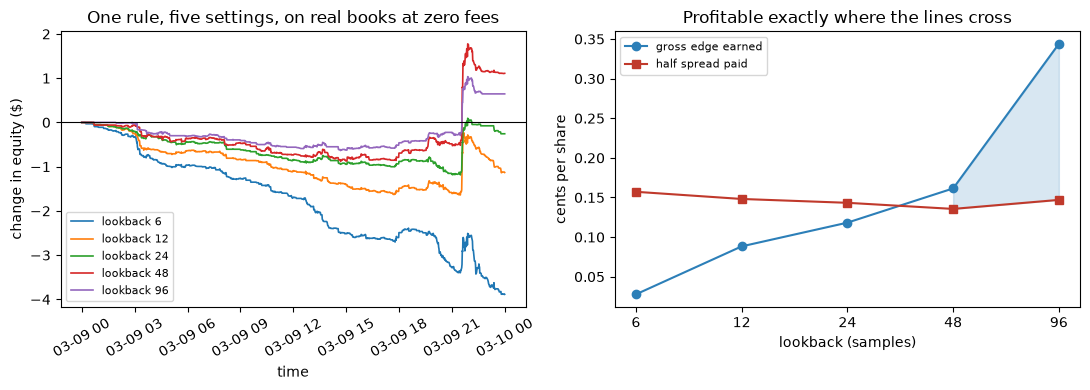

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for lookback in LOOKBACKS:
    line = results[lookback].equity.to_pandas().sort_values("ts")
    axes[0].plot(line.ts, line.equity - line.equity.iloc[0], lw=1.2,
                 label=f"lookback {lookback}")
axes[0].axhline(0.0, color="black", lw=0.8)
axes[0].set_title("One rule, five settings, on real books at zero fees")
axes[0].set_xlabel("time")
axes[0].set_ylabel("change in equity ($)")
axes[0].tick_params(axis="x", labelrotation=30)
axes[0].legend(fontsize=8)
axes[1].plot(sweep.lookback, sweep.gross_c_per_share, marker="o", color="#2c7fb8",
             label="gross edge earned")
axes[1].plot(sweep.lookback, sweep.cost_c_per_share, marker="s", color="#c0392b",
             label="half spread paid")
axes[1].fill_between(sweep.lookback, sweep.gross_c_per_share, sweep.cost_c_per_share,
                     where=sweep.gross_c_per_share >= sweep.cost_c_per_share,
                     color="#2c7fb8", alpha=0.18)
axes[1].set_xscale("log", base=2)
axes[1].set_xticks(list(LOOKBACKS))
axes[1].set_xticklabels([str(value) for value in LOOKBACKS])
axes[1].set_title("Profitable exactly where the lines cross")
axes[1].set_xlabel("lookback (samples)")
axes[1].set_ylabel("cents per share")
axes[1].legend(fontsize=8)
fig.tight_layout()

In [46]:
real.close()

---

# What to take away

**On how the price is made.** Polymarket is a plain central limit order book:
bids and asks with sizes, and a spread between them at which nothing trades. A
share pays one dollar or nothing, so the price is a probability and YES plus NO
must sum to one. The mid is a summary, not a price you can transact at.

**On what a trade costs.** Buy at the ask and sell at the bid and you have paid
the spread, whatever happened to the mid in between. On the real books above,
half the spread runs from under one percent of the mid on liquid markets to
double digits at the cheap end. Any fee sits on top of that, and on the venues
that charge one it follows a `p * (1 - p)` curve that peaks exactly where most
trading happens.

**On execution being the strategy.** Part 2's four runs saw the same book and
the same outcome and landed in four different places, purely on how the orders
were sent. Entry price, exit price, latency and fill probability are not details
to be added later; they are most of the result.

**On the one number that decides it.** A strategy makes money when its gross
edge per share exceeds the half-spread it pays, and Part 3's sweep shows nothing
else mattering. Across five settings of one rule the gross edge stayed near a
dollar while the spread bill fell from \$4.35 to \$0.49, and the sign of the
result flipped exactly where earnings per share crossed cost per share. Trading
more often did not find more signal; it found the same signal and paid for it
repeatedly.

**On believing your own results.** The winning setting made 65 cents, and every
check available said not to trust it: cut into walk-forward windows its median
was negative in both train and holdout, and the deflated Sharpe fell from a 84%
chance of being genuine to 37% purely on admitting five settings were tried. The
discipline is the same whatever the sign — pin the input so every run reads
identical bytes, gate settlement on when the outcome was actually knowable, score
a choice on data it never saw, deflate by the number of things you tried, and
verify that the run reproduces.

**On what you hand to someone else.** `result.report()` writes all of that as
one self-contained page — fidelity and pin first, then performance, then every
order and fill, then the configuration verbatim. It is a better unit of record
than a notebook, because it opens years later with no environment to rebuild,
and it puts the caveats where a reader sees them rather than where an author
remembers to mention them.

**Where to go next.** The obvious research directions this article does not
take: obtain both token books and test the parity trade that Part 1 describes;
capture full depth rather than the top level and study the size you can actually
trade; capture over months rather than a day so that positions can be held to
resolution and settlement P&L becomes the scoreboard; and, most promising given
what the cost budget says, stop crossing the spread at all and study whether
the maker side is where the money is — which requires delta-level data, because
it requires queue position.

The full cookbook this article is drawn from lives at
[h5i-db-cookbook](https://github.com/h5i-dev/h5i-db-cookbook), with a longer
treatment of each of these in `notebooks/05_prediction_markets/`.